In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the CSV file
opendengue = pd.read_csv("masterDB_V1.3.csv", encoding="latin1")
opendengue.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
0,ARGENTINA,12.0,Salta,445.0,Oran,4781.0,2019-07-21,2019-07-27,2.0,V1_0_MOH_PAHO_SUB_transformed.csv,Total,MOH-ARG-2019-Y01-00
1,ARGENTINA,12.0,Misiones,442.0,Iguazu,4728.0,2019-09-01,2019-09-07,1.0,V1_0_MOH_PAHO_SUB_transformed.csv,Total,MOH-ARG-2019-Y01-00
2,ARGENTINA,12.0,Salta,445.0,Grl. Jose De San Martin,4773.0,2019-07-14,2019-07-20,1.0,V1_0_MOH_PAHO_SUB_transformed.csv,Total,MOH-ARG-2019-Y01-00
3,ARGENTINA,12.0,Jujuy,438.0,Ledesma,4649.0,2019-07-14,2019-07-20,1.0,V1_0_MOH_PAHO_SUB_transformed.csv,Total,MOH-ARG-2019-Y01-00
4,ARGENTINA,12.0,Salta,445.0,Grl. Jose De San Martin,4773.0,2019-06-30,2019-07-06,3.0,V1_0_MOH_PAHO_SUB_transformed.csv,Total,MOH-ARG-2019-Y01-00


In [3]:
opendengue["adm_0_name"].unique()

array(['ARGENTINA', 'BOLIVIA', 'COLOMBIA', 'COSTA RICA',
       'DOMINICAN REPUBLIC', 'ECUADOR', 'GUATEMALA', 'MEXICO',
       'NICARAGUA', 'PANAMA', 'PERU', 'ANGUILLA',
       'UNITED STATES OF AMERICA', 'URUGUAY', 'BERMUDA', 'GUADELOUPE',
       'DOMINICA', 'SAINT BARTHELEMY', 'JAMAICA', 'BARBADOS',
       'EL SALVADOR', 'MONTSERRAT', 'BRAZIL', 'PARAGUAY',
       'VIRGIN ISLANDS (US)', 'VIRGIN ISLANDS (UK)', 'VENEZUELA',
       'BELIZE', 'MARTINIQUE', 'PUERTO RICO', 'SAINT MARTIN',
       'FRENCH GUIANA', 'BAHAMAS', 'CAYMAN ISLANDS', 'HONDURAS',
       'TRINIDAD AND TOBAGO', 'SAINT VINCENT AND THE GRENADINES',
       'GUYANA', 'ANTIGUA AND BARBUDA', 'GRENADA',
       'TURKS AND CAICOS ISLANDS', 'CURACAO', 'SINT MAARTEN',
       'SAINT LUCIA', 'ARUBA', 'HAITI', 'SAINT KITTS AND NEVIS', 'CHILE',
       'SURINAME', 'BONAIRE, SAINT EUSTATIUS AND SABA', 'CUBA',
       'AMERICAN SAMOA', 'AUSTRALIA', "LAO PEOPLE'S DEMOCRATIC REPUBLIC",
       'BANGLADESH', 'BHUTAN', 'BRUNEI DARUSSALAM', 'CA

In [4]:
southeast_asia_countries = [
    "VIETNAM", "THAILAND", "MALAYSIA", "INDONESIA", "PHILIPPINES",
    "SINGAPORE", "MYANMAR", "CAMBODIA", "LAOS", "BRUNEI", "TIMOR-LESTE"
]

# Group by country and count cases
cases_by_country = opendengue.groupby("adm_0_name")["dengue_total"].sum().reset_index()

# Sort by number of cases descending
cases_by_country = cases_by_country.sort_values("dengue_total", ascending=False)
cases_by_country = cases_by_country[cases_by_country["adm_0_name"].isin(southeast_asia_countries)]

print(cases_by_country)
# --> Choose Vietnam and Thailand as the two countries with the most cases

      adm_0_name  dengue_total
56     INDONESIA    10166238.0
92   PHILIPPINES     7859991.0
114     THAILAND     7174162.0
64      MALAYSIA     3454734.0
76       MYANMAR     1082420.0
21      CAMBODIA      887656.0
106    SINGAPORE      560912.0
115  TIMOR-LESTE       23531.0


## Process Vietnam (good data, chosen)

In [5]:
vietnam_cases = opendengue[opendengue["adm_0_name"] == "VIET NAM"]
vietnam_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
100043,VIET NAM,264.0,An Giang,3326.0,NaN,NaN,2007-01-01,2007-01-31,297.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
100044,VIET NAM,264.0,An Giang,3326.0,NaN,NaN,2007-05-01,2007-05-31,771.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
100045,VIET NAM,264.0,An Giang,3326.0,NaN,NaN,2008-10-01,2008-10-31,247.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
100046,VIET NAM,264.0,An Giang,3326.0,NaN,NaN,1994-05-01,1994-05-31,131.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
100047,VIET NAM,264.0,An Giang,3326.0,NaN,NaN,1994-08-01,1994-08-31,390.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [6]:
# Which cities in Vietnam have the most cases?
city_cases_vietnam = vietnam_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_vietnam.sort_values("dengue_total", ascending=False)
# Choose Ho Chi Minh City

,adm_1_name,dengue_total
29,Ho Chi Minh City,115304.0
58,Tien Giang,83373.0
6,Ben Tre,82532.0
19,Dong Thap,72717.0
10,Binh Thuan,68206.0
...,...,...
38,Lao Cai,15.0
3,Bac Kan,7.0
17,Dien Bien,5.0
35,Lai Chau,4.0


In [7]:
# Sort by calendar_start_date
hochiminh_cases = vietnam_cases[vietnam_cases["adm_1_name"] == "Ho Chi Minh City"].sort_values("calendar_start_date")
hochiminh_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
132711,VIET NAM,264.0,Ho Chi Minh City,3352.0,NaN,NaN,1994-02-01,1994-02-28,73.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
132714,VIET NAM,264.0,Ho Chi Minh City,3352.0,NaN,NaN,1994-03-01,1994-03-31,39.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
132604,VIET NAM,264.0,Ho Chi Minh City,3352.0,NaN,NaN,1994-04-01,1994-04-30,22.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
133686,VIET NAM,264.0,Ho Chi Minh City,3352.0,NaN,NaN,1994-05-01,1994-05-31,49.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
132605,VIET NAM,264.0,Ho Chi Minh City,3352.0,NaN,NaN,1994-06-01,1994-06-30,87.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [8]:
# Sort by calendar_start_date and filter only weekly data
vietnam_cases["calendar_start_date"] = pd.to_datetime(vietnam_cases["calendar_start_date"])
vietnam_cases["calendar_end_date"] = pd.to_datetime(vietnam_cases["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
vietnam_cases["period_days"] = (vietnam_cases["calendar_end_date"] - vietnam_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_vietnam_cases = vietnam_cases[
    vietnam_cases["adm_1_name"].isnull() & 
    (vietnam_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_vietnam_cases = weekly_vietnam_cases[selected_columns]
weekly_vietnam_cases.head()

,calendar_start_date,calendar_end_date,dengue_total
139693,2016-01-03,2016-01-09,2105.0
139600,2016-01-10,2016-01-16,2545.0
139690,2016-01-17,2016-01-23,2838.0
139670,2016-01-24,2016-01-30,2740.0
139687,2016-01-31,2016-02-06,2421.0


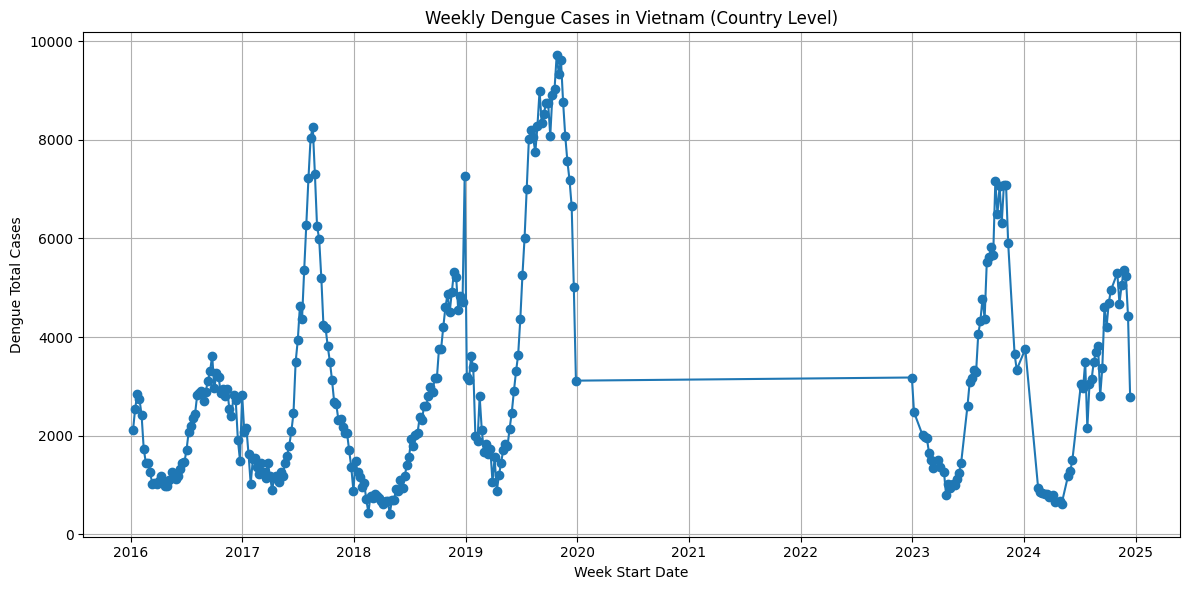

In [10]:
import matplotlib.pyplot as plt

# Visualize weekly_vietnam_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_vietnam_cases["calendar_end_date"], weekly_vietnam_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

### Weekly cases

48


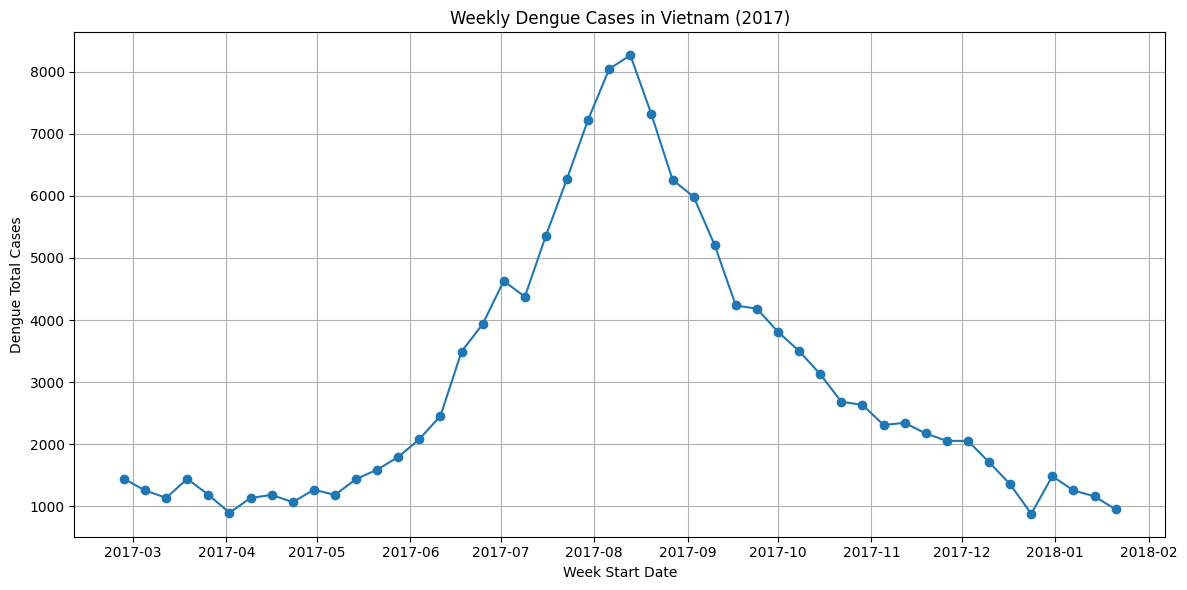

       calendar_start_date calendar_end_date  dengue_total  \
139515          2017-02-26        2017-03-04        1444.0   
139531          2017-03-05        2017-03-11        1256.0   
139544          2017-03-12        2017-03-18        1137.0   
139518          2017-03-19        2017-03-25        1442.0   
139503          2017-03-26        2017-04-01        1187.0   
139520          2017-04-02        2017-04-08         897.0   
139550          2017-04-09        2017-04-15        1135.0   
139686          2017-04-16        2017-04-22        1185.0   
139623          2017-04-23        2017-04-29        1066.0   
139598          2017-04-30        2017-05-06        1269.0   
139608          2017-05-07        2017-05-13        1184.0   
139599          2017-05-14        2017-05-20        1439.0   
139683          2017-05-21        2017-05-27        1591.0   
139680          2017-05-28        2017-06-03        1795.0   
139662          2017-06-04        2017-06-10        2083.0   
139659  

In [12]:
# Select data from a specific date range
start_date = "2017-02-25"
end_date = "2018-02-01"
chosen_range = weekly_vietnam_cases[
    (weekly_vietnam_cases["calendar_start_date"] >= start_date) &
    (weekly_vietnam_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2017)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../vietnam/vietnam_data_1.csv", index=False)
print(chosen_range)

In [70]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

139515    7.275865
139531    7.901377
139544    8.252707
139518    8.571681
139503    8.774468
Name: CumulativeHumanInfected, dtype: float64
139515    1444.0
139531    2700.0
139544    3837.0
139518    5279.0
139503    6466.0
Name: CumulativeHumanInfected, dtype: float64
139515    1444.0
139531    2700.0
139544    3837.0
139518    5279.0
139503    6466.0
Name: CumulativeHumanInfected, dtype: float64


48


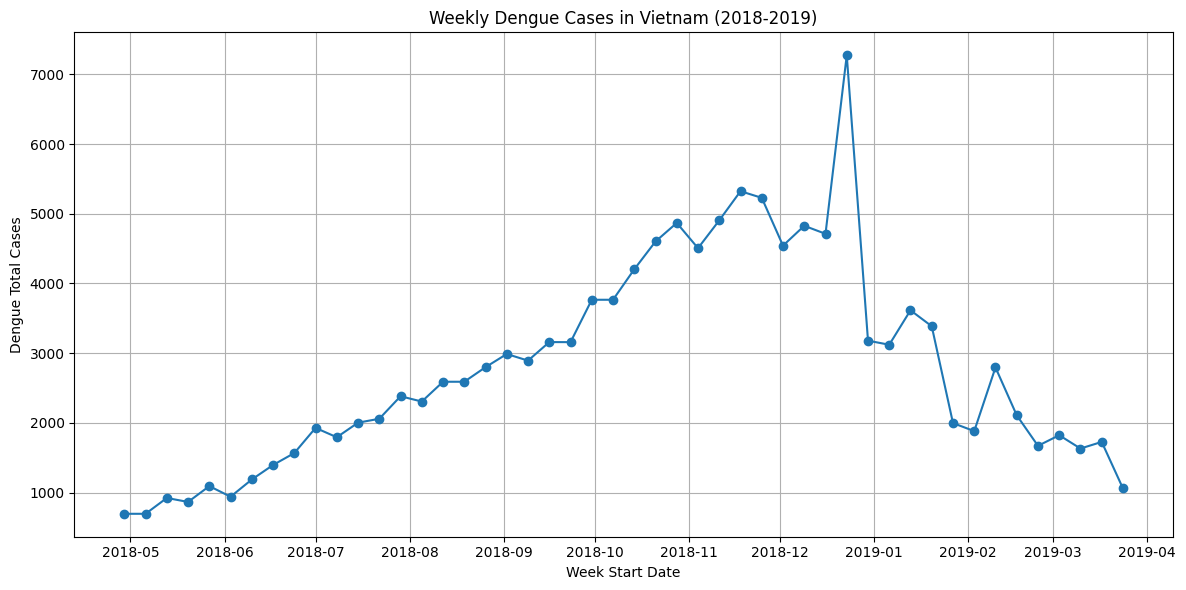

       calendar_start_date calendar_end_date  dengue_total  \
140334          2018-04-29        2018-05-05         696.0   
140335          2018-05-06        2018-05-12         696.0   
140336          2018-05-13        2018-05-19         923.0   
140337          2018-05-20        2018-05-26         866.0   
140338          2018-05-27        2018-06-02        1093.0   
140339          2018-06-03        2018-06-09         941.0   
140340          2018-06-10        2018-06-16        1188.0   
140341          2018-06-17        2018-06-23        1396.0   
140342          2018-06-24        2018-06-30        1567.0   
140343          2018-07-01        2018-07-07        1928.0   
140331          2018-07-08        2018-07-14        1794.0   
140332          2018-07-15        2018-07-21        2003.0   
140333          2018-07-22        2018-07-28        2059.0   
140347          2018-07-29        2018-08-04        2382.0   
140344          2018-08-05        2018-08-11        2306.0   
140345  

In [13]:
# Select data from a specific date range
start_date = "2018-04-25"
end_date = "2019-04-01"
chosen_range = weekly_vietnam_cases[
    (weekly_vietnam_cases["calendar_start_date"] >= start_date) &
    (weekly_vietnam_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2018-2019)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../vietnam/vietnam_data_2.csv", index=False)
print(chosen_range)

In [11]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

140334    6.546785
140335    7.239215
140336    7.747597
140337    8.065265
140338    8.360539
Name: CumulativeHumanInfected, dtype: float64
140334     696.0
140335    1392.0
140336    2315.0
140337    3181.0
140338    4274.0
Name: CumulativeHumanInfected, dtype: float64
140334     696.0
140335    1392.0
140336    2315.0
140337    3181.0
140338    4274.0
Name: CumulativeHumanInfected, dtype: float64


48


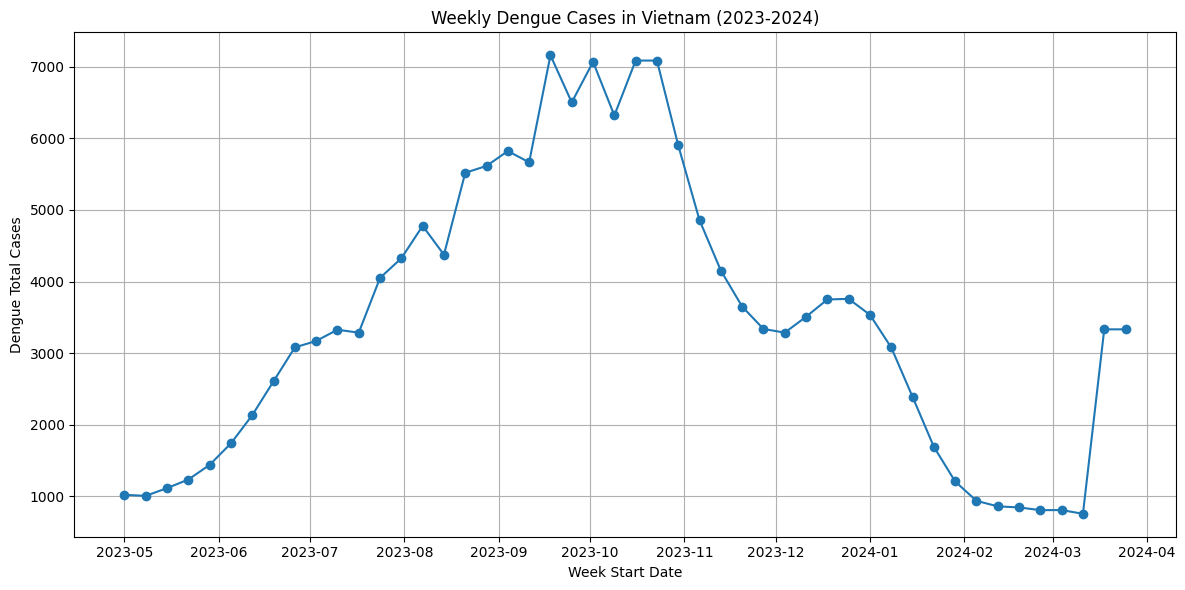

In [12]:
# Select data from a specific date range
start_date = "2023-04-25"
end_date = "2024-03-25"
chosen_range = weekly_vietnam_cases[
    (weekly_vietnam_cases["calendar_start_date"] >= start_date) &
    (weekly_vietnam_cases["calendar_end_date"] <= end_date)
]

# Align calendar_start_date to Monday (or the weekday you use for full_weeks)
chosen_range = chosen_range.copy()
chosen_range["calendar_start_date"] = pd.to_datetime(chosen_range["calendar_start_date"])
chosen_range["calendar_start_date"] = chosen_range["calendar_start_date"] - pd.to_timedelta(chosen_range["calendar_start_date"].dt.weekday, unit='D')

# Set as index
chosen_range = chosen_range.set_index("calendar_start_date")
full_weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
chosen_range = chosen_range.reindex(full_weeks)

# Fill missing dengue_total with interpolation or median
chosen_range["dengue_total"] = chosen_range["dengue_total"].interpolate(method="quadratic")
chosen_range["dengue_total"] = chosen_range["dengue_total"].fillna(chosen_range["dengue_total"].median()).abs()

# Reconstruct calendar_end_date if needed
chosen_range["calendar_end_date"] = chosen_range.index + pd.Timedelta(days=6)

# Reset index for further use
chosen_range = chosen_range.reset_index().rename(columns={"index": "calendar_start_date"})

print(len(chosen_range))
plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2023-2024)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../vietnam/vietnam_data_3.csv", index=False)

In [13]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

0    6.926577
1    7.612337
2    8.050384
3    8.381832
4    8.666303
Name: CumulativeHumanInfected, dtype: float64
0    1018.0
1    2022.0
2    3134.0
3    4366.0
4    5803.0
Name: CumulativeHumanInfected, dtype: float64
0    1018.0
1    2022.0
2    3134.0
3    4366.0
4    5803.0
Name: CumulativeHumanInfected, dtype: float64


### Monthly cases

In [ ]:
# Convert weekly_vietnam_cases to monthly data by summing dengue_total per month
monthly_country_cases = (
    weekly_vietnam_cases
    .assign(year_month=weekly_vietnam_cases["calendar_start_date"].dt.to_period("M"))
    .groupby("year_month")["dengue_total"]
    .sum()
    .reset_index()
)

# Convert year_month back to timestamp for plotting if needed
monthly_country_cases["year_month"] = monthly_country_cases["year_month"].dt.to_timestamp()

monthly_country_cases

,year_month,dengue_total
0,2016-01-01,12649.0
1,2016-02-01,5880.0
2,2016-03-01,4155.0
3,2016-04-01,4232.0
4,2016-05-01,5868.0
...,...,...
67,2024-08-01,14166.0
68,2024-09-01,19704.0
69,2024-10-01,10246.0
70,2024-11-01,20327.0


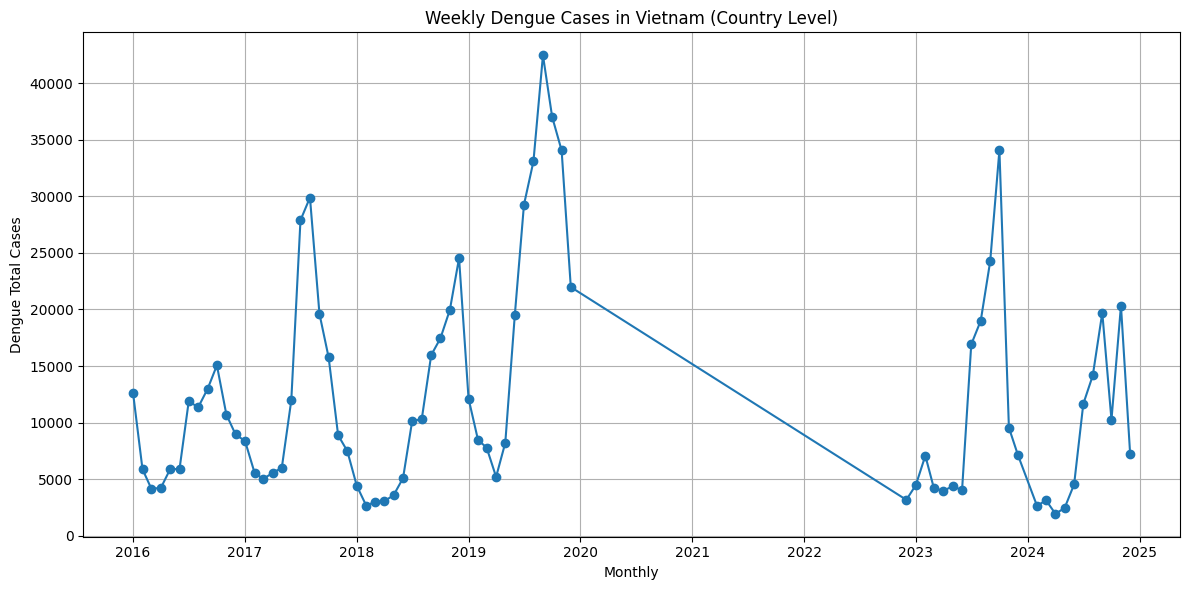

In [45]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(monthly_country_cases["year_month"], monthly_country_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (Country Level)")
plt.xlabel("Monthly")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

12


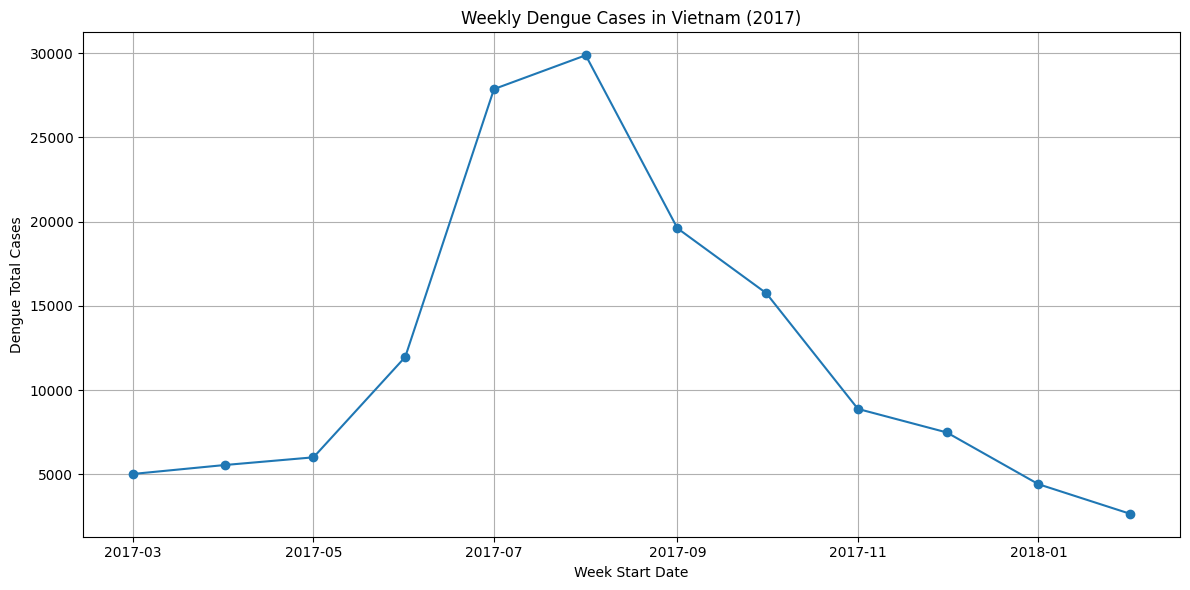

In [50]:
# Select data from a specific date range
start_date = "2017-03-01"
end_date = "2018-02-01"
chosen_range = monthly_country_cases[
    (monthly_country_cases["year_month"] >= start_date) &
    (monthly_country_cases["year_month"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2017)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("vietnam_data.csv", index=False)

13


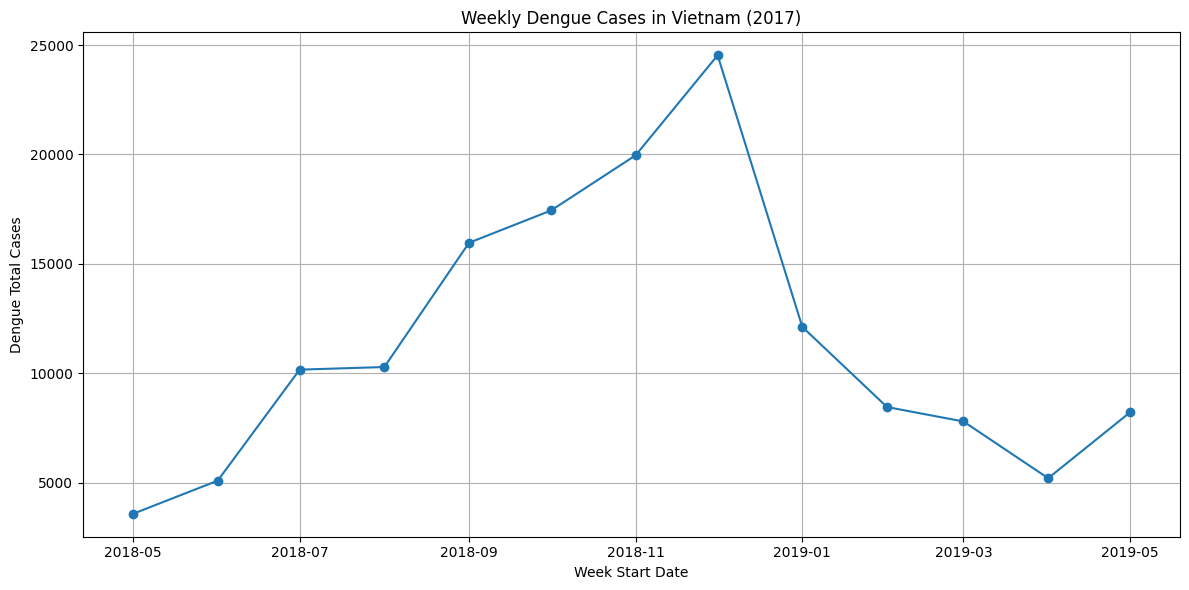

In [21]:
# Select data from a specific date range
start_date = "2018-05-01"
end_date = "2019-05-01"
chosen_range = monthly_country_cases[
    (monthly_country_cases["year_month"] >= start_date) &
    (monthly_country_cases["year_month"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2017)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## Process Brazil

In [76]:
brazil_cases = opendengue[opendengue["adm_0_name"] == "BRAZIL"]
brazil_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
62731,BRAZIL,37.0,NaN,NaN,NaN,NaN,2013-12-29,2014-01-04,4570.0,V1_0_paho_for_opendengue.csv,Total,WHOPAHO-ALL-20142022-W01-01
62780,BRAZIL,37.0,NaN,NaN,NaN,NaN,2016-01-03,2016-01-09,72350.0,V1_0_paho_for_opendengue.csv,Total,WHOPAHO-ALL-20142022-W01-01
62794,BRAZIL,37.0,NaN,NaN,NaN,NaN,2017-01-01,2017-01-07,11969.0,V1_0_paho_for_opendengue.csv,Total,WHOPAHO-ALL-20142022-W01-01
62806,BRAZIL,37.0,NaN,NaN,NaN,NaN,2019-12-29,2020-01-04,20844.0,V1_0_paho_for_opendengue.csv,Total,WHOPAHO-ALL-20142022-W01-01
62862,BRAZIL,37.0,NaN,NaN,NaN,NaN,2017-12-31,2018-01-06,7588.0,V1_0_paho_for_opendengue.csv,Total,WHOPAHO-ALL-20142022-W01-01


In [77]:
# Which cities in Vietnam have the most cases?
city_cases_brazil = brazil_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_brazil.sort_values("dengue_total", ascending=False).head()
# Choose Ho Chi Minh City

,adm_1_name,dengue_total
1,Alagoas,55456.0
4,Bahia,44249.0
12,Minas Gerais,42670.0
7,Espirito Santo,37824.0
16,Pernambuco,26666.0


In [78]:
# Sort by calendar_start_date and filter only weekly data
brazil_cases["calendar_start_date"] = pd.to_datetime(brazil_cases["calendar_start_date"])
brazil_cases["calendar_end_date"] = pd.to_datetime(brazil_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
brazil_cases["period_days"] = (brazil_cases["calendar_end_date"] - brazil_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_brazil_cases = brazil_cases[
    brazil_cases["adm_1_name"].isnull() & 
    (brazil_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_brazil_cases = weekly_brazil_cases[selected_columns]
weekly_brazil_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total
62731,BRAZIL,2013-12-29,2014-01-04,4570.0
63320,BRAZIL,2014-01-05,2014-01-11,6100.0
63639,BRAZIL,2014-01-12,2014-01-18,6961.0
63787,BRAZIL,2014-01-19,2014-01-25,8374.0
64081,BRAZIL,2014-01-26,2014-02-01,9577.0


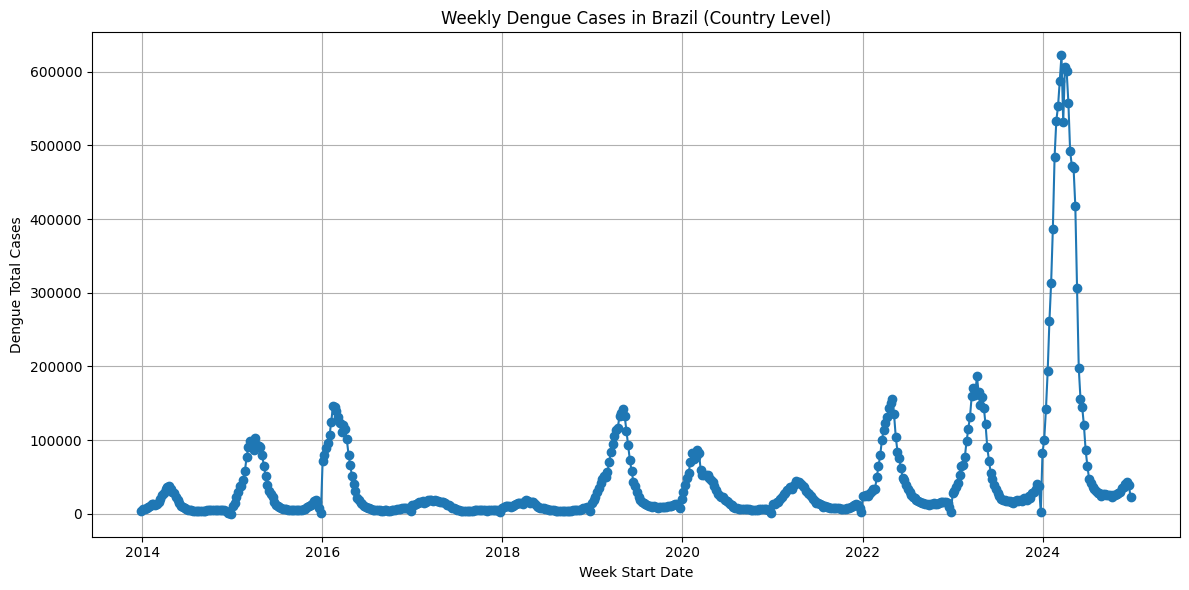

In [79]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_brazil_cases["calendar_start_date"], weekly_brazil_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

### Weekly cases

48


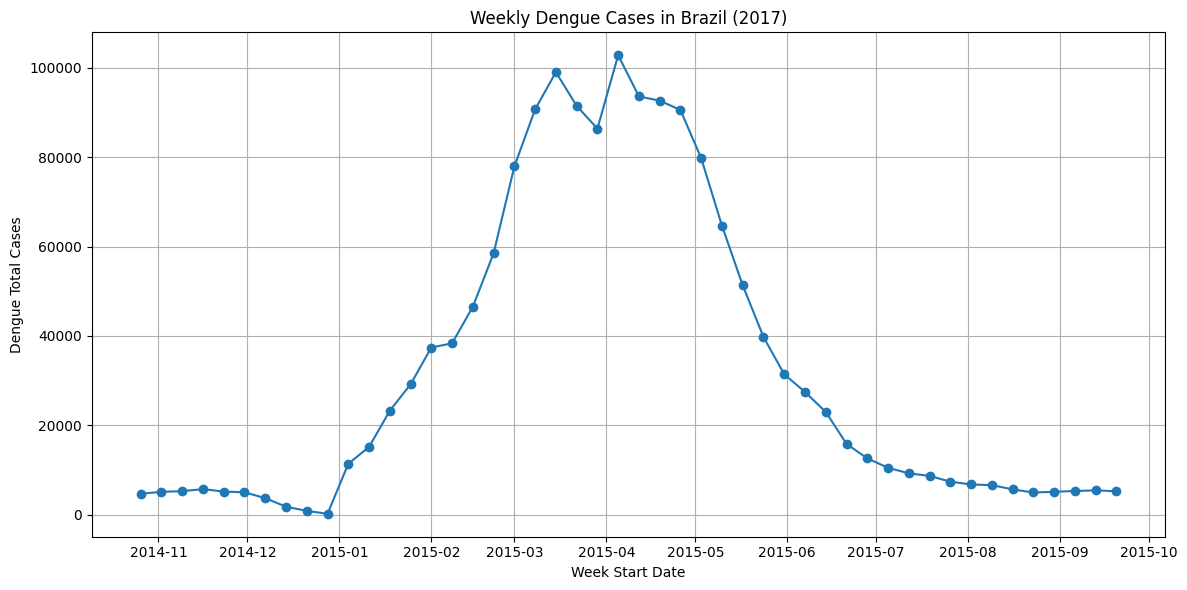

In [117]:
# Select data from a specific date range
start_date = "2014-10-25"
end_date = "2015-10-01"
chosen_range = weekly_brazil_cases[
    (weekly_brazil_cases["calendar_start_date"] >= start_date) &
    (weekly_brazil_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil (2017)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../brazil/brazil_data_1.csv", index=False)

48


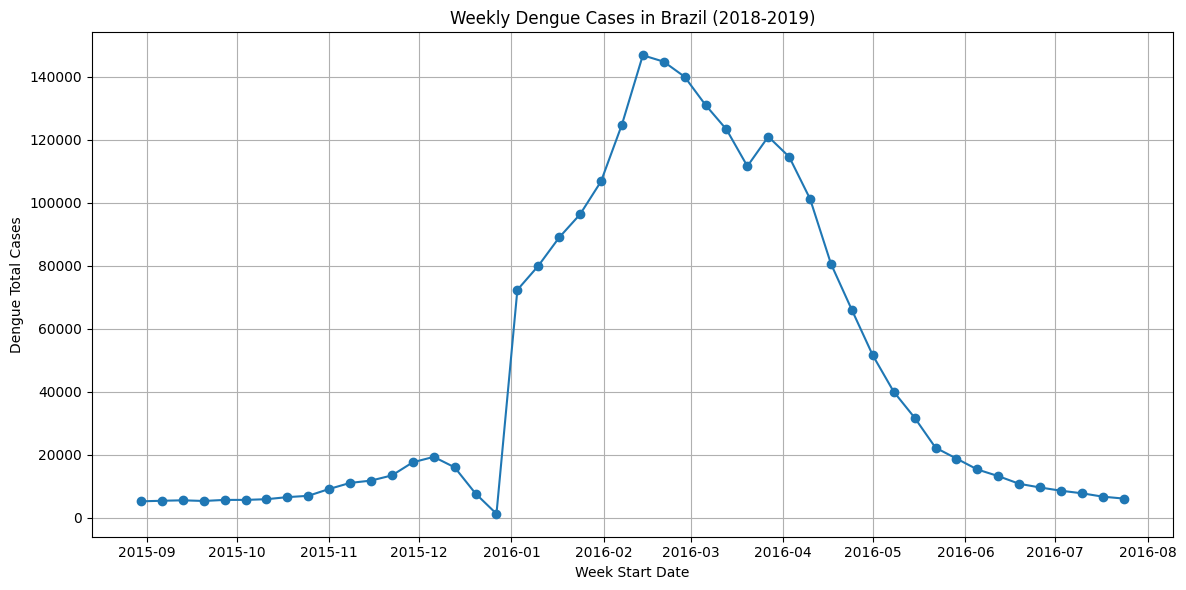

In [86]:
# Select data from a specific date range
start_date = "2015-08-25"
end_date = "2016-08-01"
chosen_range = weekly_brazil_cases[
    (weekly_brazil_cases["calendar_start_date"] >= start_date) &
    (weekly_brazil_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil (2018-2019)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../brazil/brazil_data_2.csv", index=False)

48


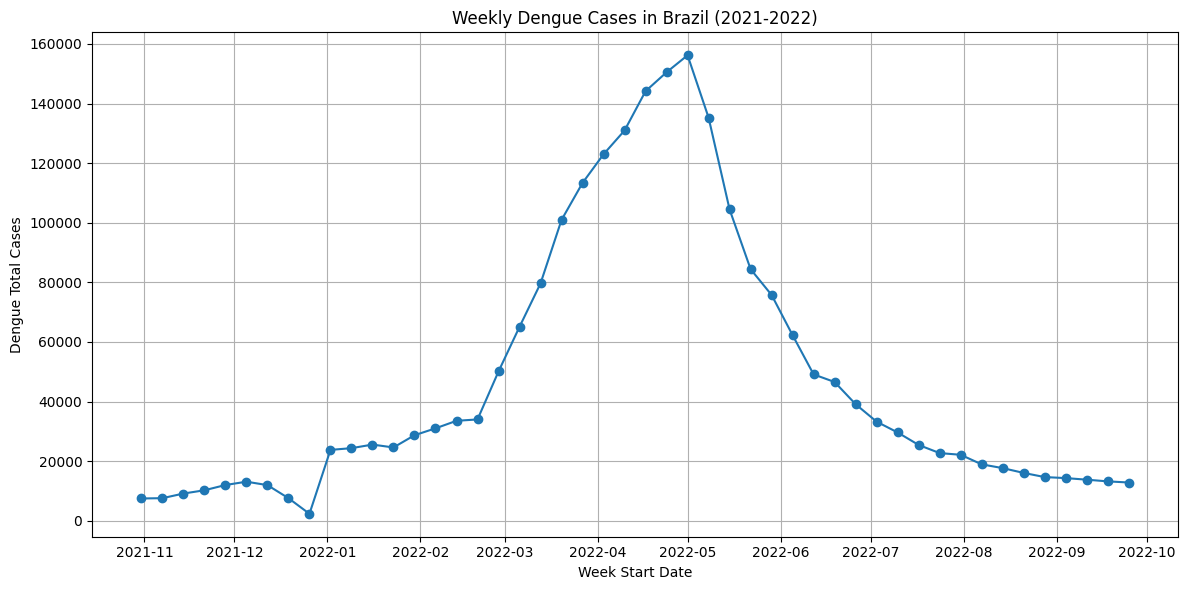

In [89]:
# Select data from a specific date range
start_date = "2021-10-25"
end_date = "2022-10-01"
chosen_range = weekly_brazil_cases[
    (weekly_brazil_cases["calendar_start_date"] >= start_date) &
    (weekly_brazil_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil (2021-2022)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../brazil/brazil_data_3.csv", index=False)

48


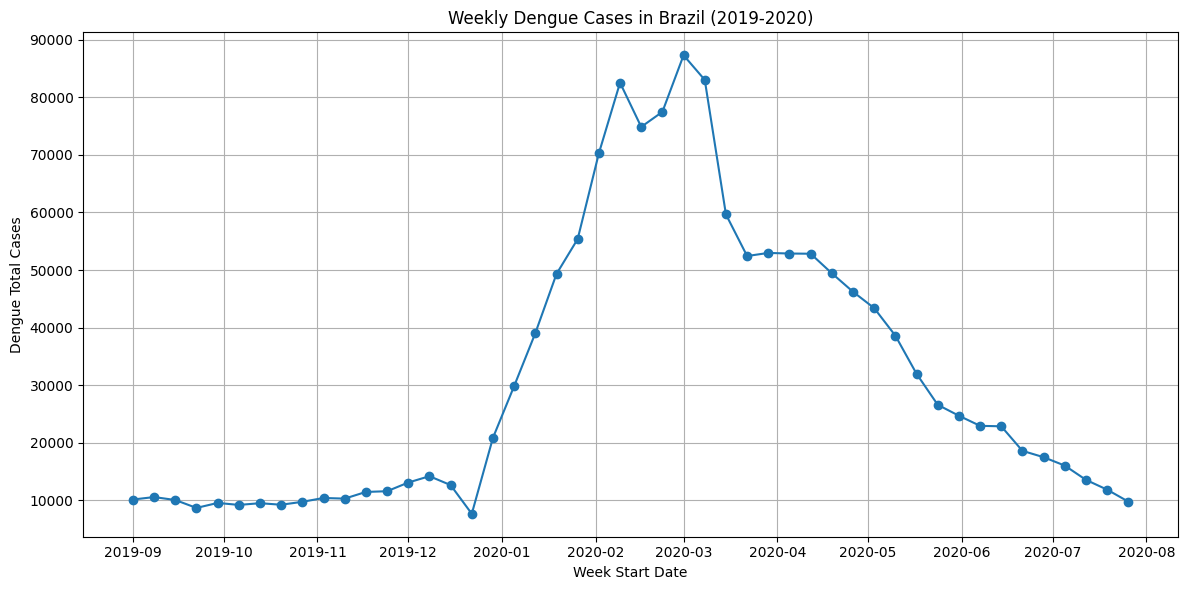

In [92]:
# Select data from a specific date range
start_date = "2019-09-01"
end_date = "2020-08-01"
chosen_range = weekly_brazil_cases[
    (weekly_brazil_cases["calendar_start_date"] >= start_date) &
    (weekly_brazil_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil (2019-2020)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../brazil/brazil_data_4.csv", index=False)

### Monthly cases

In [33]:
# Convert weekly_brazil_cases to monthly data by summing dengue_total per month
monthly_brazil_cases = (
    weekly_brazil_cases
    .assign(year_month=weekly_brazil_cases["calendar_start_date"].dt.to_period("M"))
    .groupby("year_month")["dengue_total"]
    .sum()
    .reset_index()
)

# Convert year_month back to timestamp for plotting if needed
monthly_brazil_cases["year_month"] = monthly_brazil_cases["year_month"].dt.to_timestamp()

monthly_brazil_cases

,year_month,dengue_total
0,2013-12-01,4570.0
1,2014-01-01,31012.0
2,2014-02-01,49796.0
3,2014-03-01,103545.0
4,2014-04-01,142066.0
...,...,...
128,2024-08-01,112158.0
129,2024-09-01,131967.0
130,2024-10-01,102415.0
131,2024-11-01,130447.0


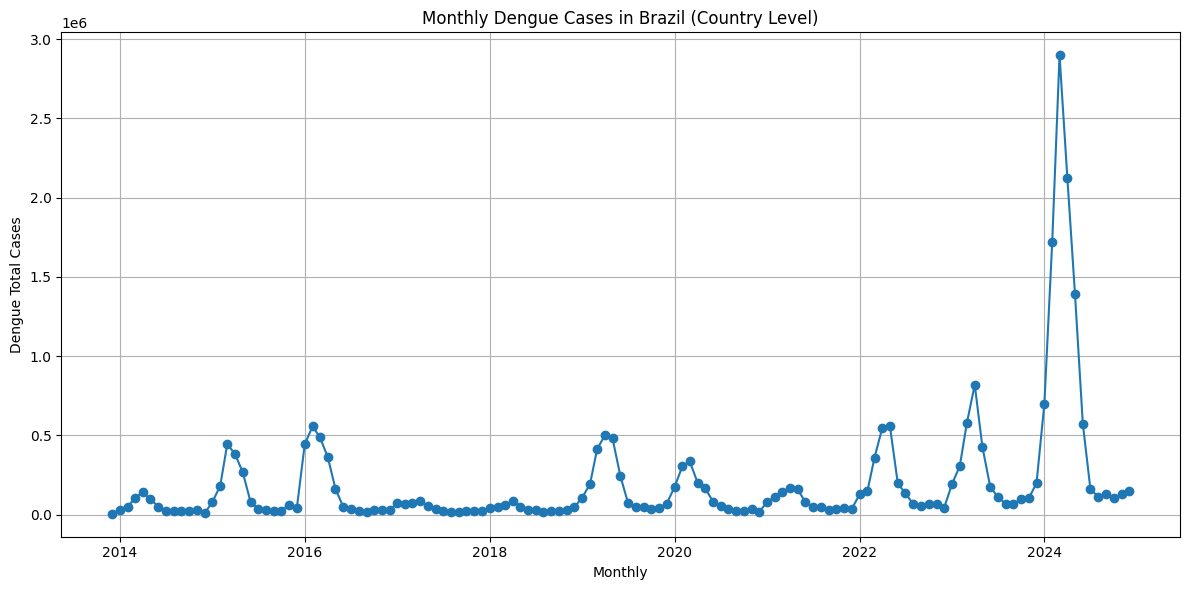

In [44]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(monthly_brazil_cases["year_month"], monthly_brazil_cases["dengue_total"], marker='o')
plt.title("Monthly Dengue Cases in Brazil (Country Level)")
plt.xlabel("Monthly")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

13


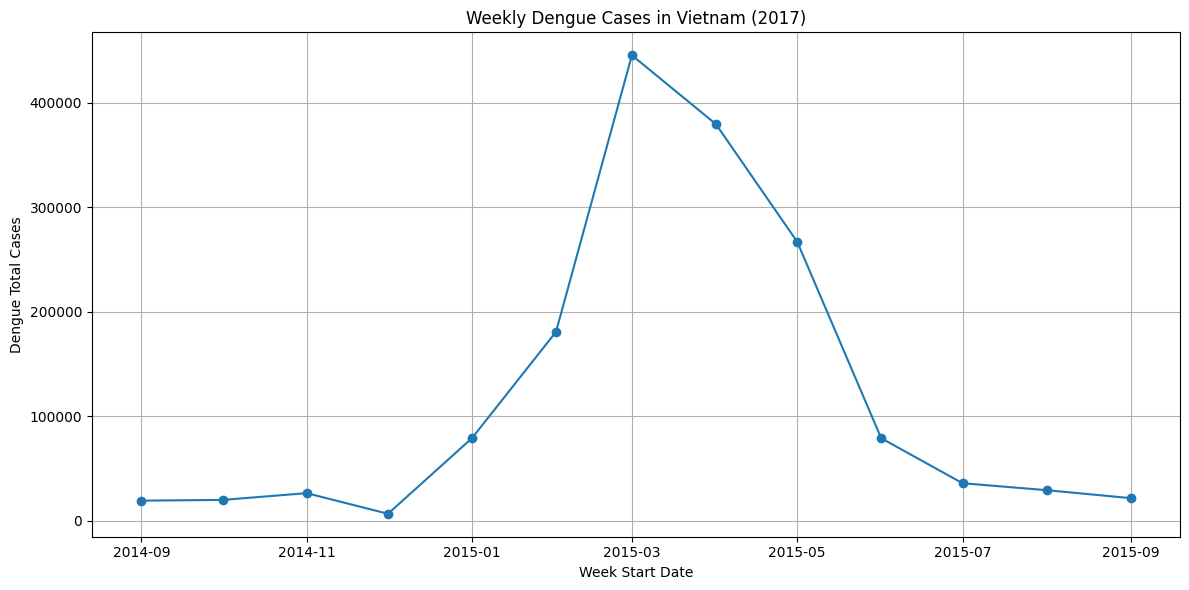

In [ ]:
# Select data from a specific date range
start_date = "2014-09-01"
end_date = "2015-08-01"
chosen_range = monthly_brazil_cases[
    (monthly_brazil_cases["year_month"] >= start_date) &
    (monthly_brazil_cases["year_month"] <= end_date)
]
print(len(chosen_range))

# Compute cumulative cases
chosen_range["cumulative_cases"] = chosen_range["dengue_total"].cumsum()
chosen_range.to_csv("brazil_cumulative_cases_2014_2015.csv", index=False)

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

13


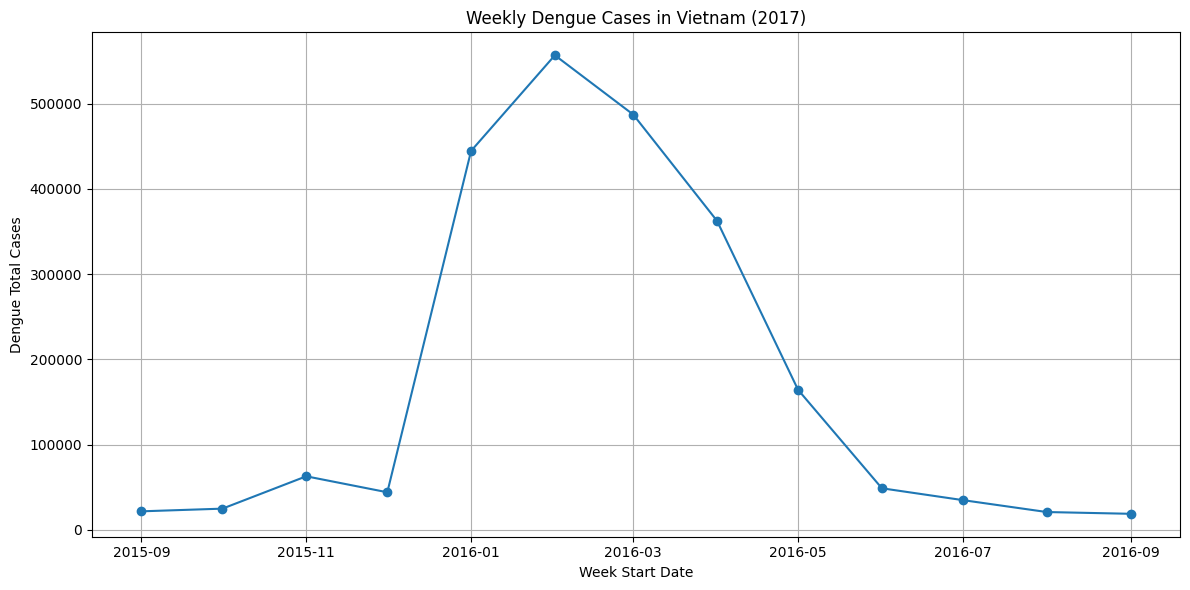

In [37]:
# Select data from a specific date range
start_date = "2015-09-01"
end_date = "2016-09-01"
chosen_range = monthly_brazil_cases[
    (monthly_brazil_cases["year_month"] >= start_date) &
    (monthly_brazil_cases["year_month"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

13


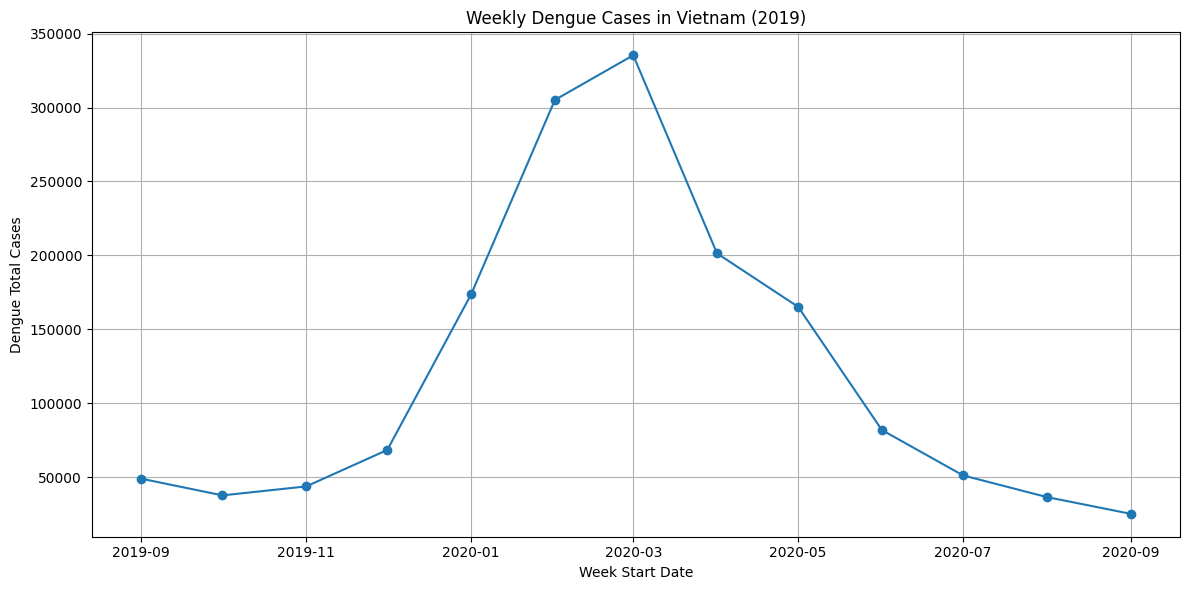

In [39]:
# Select data from a specific date range
start_date = "2019-09-01"
end_date = "2020-09-01"
chosen_range = monthly_brazil_cases[
    (monthly_brazil_cases["year_month"] >= start_date) &
    (monthly_brazil_cases["year_month"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Vietnam (2019)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

13


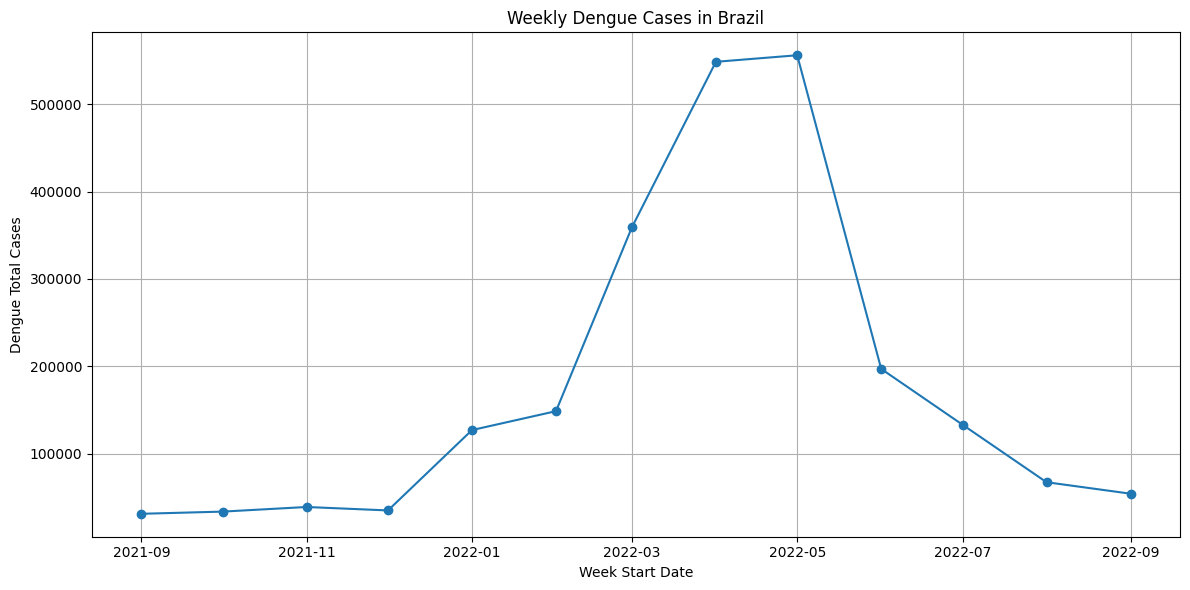

In [40]:
# Select data from a specific date range
start_date = "2021-09-01"
end_date = "2022-09-01"
chosen_range = monthly_brazil_cases[
    (monthly_brazil_cases["year_month"] >= start_date) &
    (monthly_brazil_cases["year_month"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["year_month"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Brazil")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## Process Philipines (good data, chosen)

In [14]:
philipines_cases = opendengue[opendengue["adm_0_name"] == "PHILIPPINES"]
philipines_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
90202,PHILIPPINES,196.0,Northern Mindanao (Region X),671670.0,Province Of Misamis Oriental,NaN,2002-12-01,2002-12-31,85.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90203,PHILIPPINES,196.0,Northern Mindanao (Region X),671670.0,Province Of Misamis Oriental,NaN,2003-01-01,2003-01-31,113.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90204,PHILIPPINES,196.0,Northern Mindanao (Region X),671670.0,Province Of Misamis Oriental,NaN,2003-02-01,2003-02-28,147.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90205,PHILIPPINES,196.0,Northern Mindanao (Region X),671670.0,Province Of Misamis Oriental,NaN,2003-03-01,2003-03-31,144.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90206,PHILIPPINES,196.0,Northern Mindanao (Region X),671670.0,Province Of Misamis Oriental,NaN,2003-04-01,2003-04-30,80.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [15]:
# Which cities in Philippines have the most cases?
city_cases_philippines = philipines_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_philippines.sort_values("dengue_total", ascending=False).head()
# Choose Manila

,adm_1_name,dengue_total
16,National Capital Region (NCR),385399.0
25,Region IV-A (CALABARZON),324934.0
24,Region III (Central Luzon),315456.0
30,Region VI (Western Visayas),249048.0
31,Region VII (Central Visayas),228574.0


In [16]:
# Sort by calendar_start_date and filter only weekly data
philipines_cases["calendar_start_date"] = pd.to_datetime(philipines_cases["calendar_start_date"])
philipines_cases["calendar_end_date"] = pd.to_datetime(philipines_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
philipines_cases["period_days"] = (philipines_cases["calendar_end_date"] - philipines_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_philippines_cases = philipines_cases[
    philipines_cases["adm_1_name"].isnull() & 
    (philipines_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_philippines_cases = weekly_philippines_cases[selected_columns]
weekly_philippines_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total
364401,PHILIPPINES,2012-12-30,2013-01-05,2101.0
364403,PHILIPPINES,2013-01-06,2013-01-12,2862.0
364404,PHILIPPINES,2013-01-13,2013-01-19,2690.0
364405,PHILIPPINES,2013-01-20,2013-01-26,2690.0
364406,PHILIPPINES,2013-01-27,2013-02-02,2815.0


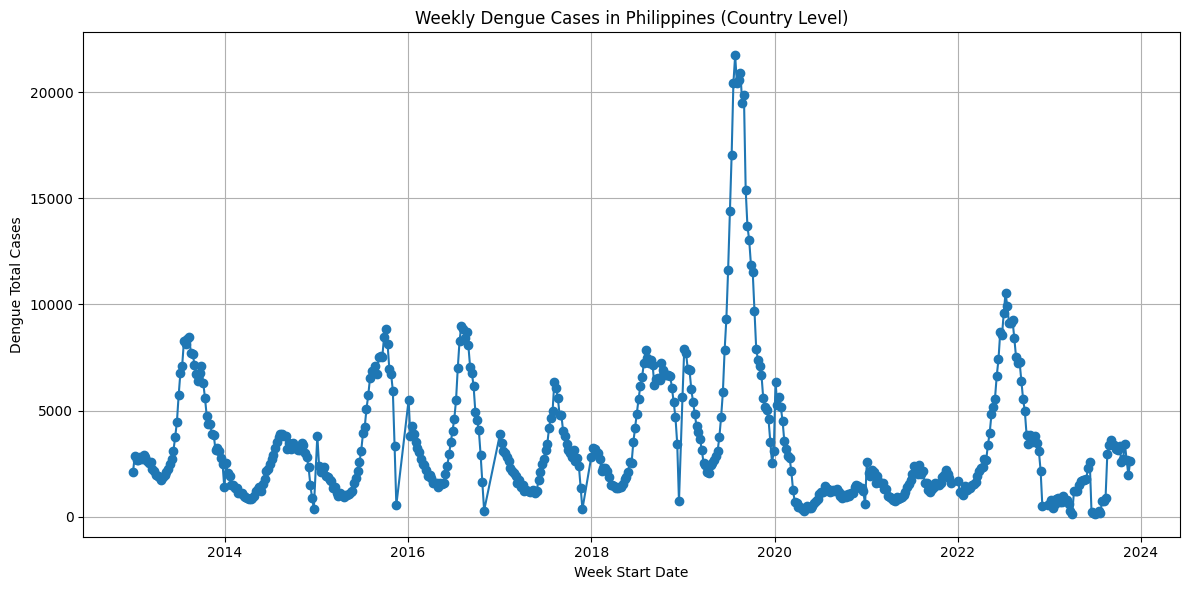

In [17]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_philippines_cases["calendar_start_date"], weekly_philippines_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Philippines (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

### Weekly cases

48


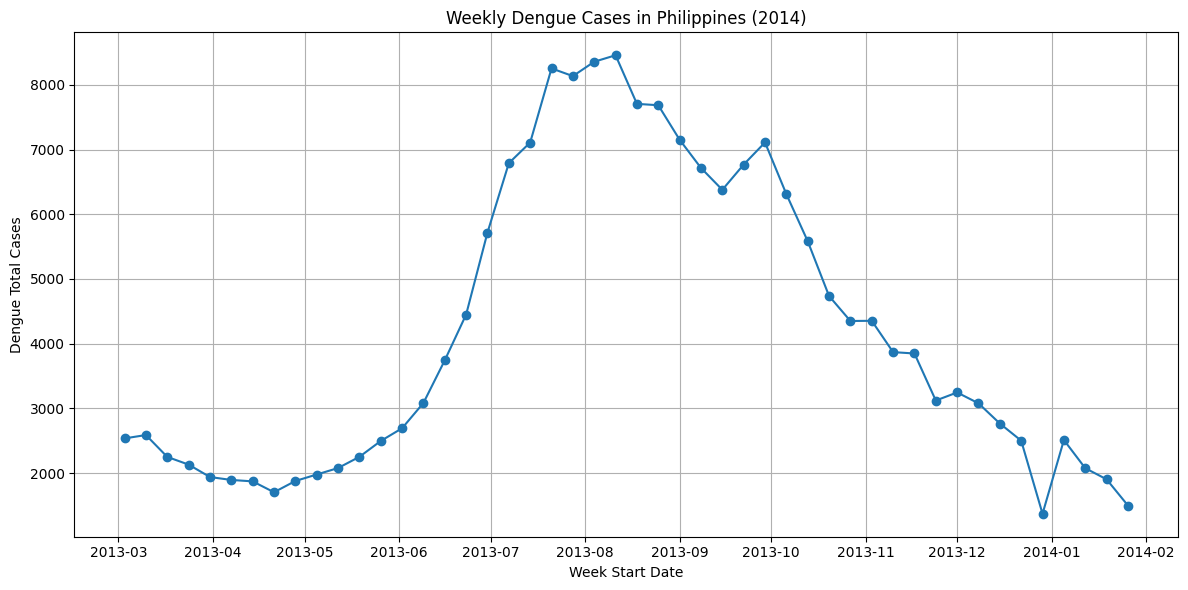

         adm_0_name calendar_start_date calendar_end_date  dengue_total  \
364413  PHILIPPINES          2013-03-03        2013-03-09        2537.0   
364414  PHILIPPINES          2013-03-10        2013-03-16        2589.0   
364415  PHILIPPINES          2013-03-17        2013-03-23        2251.0   
364416  PHILIPPINES          2013-03-24        2013-03-30        2132.0   
364417  PHILIPPINES          2013-03-31        2013-04-06        1940.0   
364419  PHILIPPINES          2013-04-07        2013-04-13        1895.0   
364420  PHILIPPINES          2013-04-14        2013-04-20        1873.0   
364421  PHILIPPINES          2013-04-21        2013-04-27        1705.0   
364422  PHILIPPINES          2013-04-28        2013-05-04        1879.0   
364424  PHILIPPINES          2013-05-05        2013-05-11        1979.0   
364425  PHILIPPINES          2013-05-12        2013-05-18        2079.0   
364426  PHILIPPINES          2013-05-19        2013-05-25        2252.0   
364427  PHILIPPINES      

In [18]:
# Select data from a specific date range
start_date = "2013-03-01"
end_date = "2014-02-01"
chosen_range = weekly_philippines_cases[
    (weekly_philippines_cases["calendar_start_date"] >= start_date) &
    (weekly_philippines_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Philippines (2014)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../philippines/philippines_data_1.csv", index=False)
print(chosen_range)

In [76]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

364413    7.839132
364414    8.542276
364415    8.906258
364416    9.160099
364417    9.345745
Name: CumulativeHumanInfected, dtype: float64
364413     2537.0
364414     5126.0
364415     7377.0
364416     9509.0
364417    11449.0
Name: CumulativeHumanInfected, dtype: float64
364413     2537.0
364414     5126.0
364415     7377.0
364416     9509.0
364417    11449.0
Name: CumulativeHumanInfected, dtype: float64


48


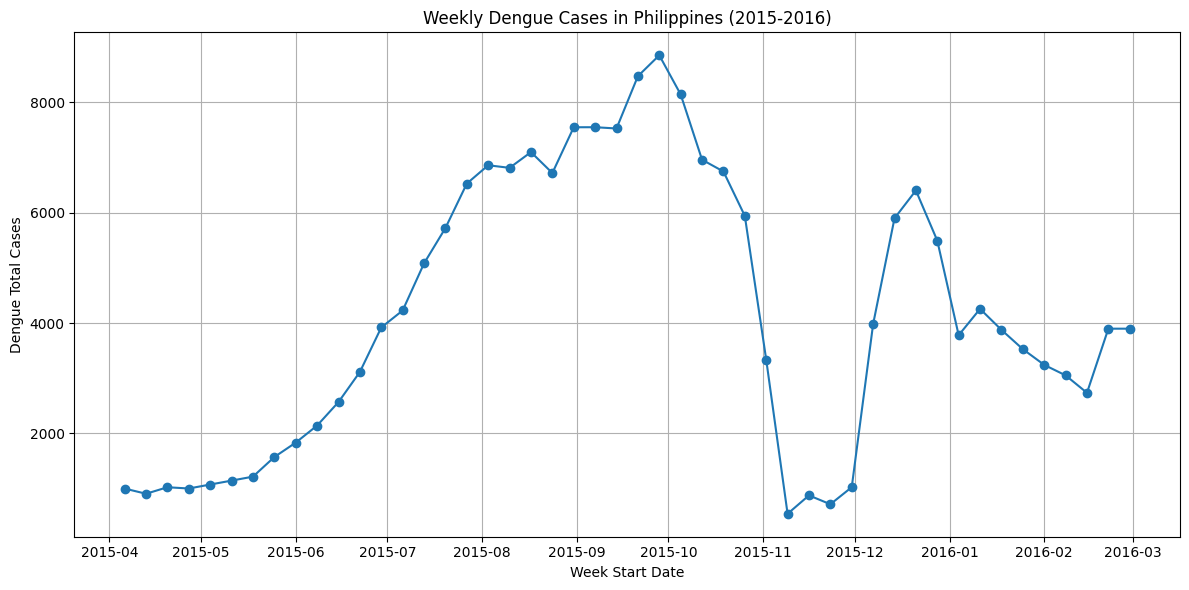

   calendar_start_date   adm_0_name calendar_end_date  dengue_total  \
0           2015-04-06  PHILIPPINES        2015-04-12   1002.000000   
1           2015-04-13  PHILIPPINES        2015-04-19    908.000000   
2           2015-04-20  PHILIPPINES        2015-04-26   1026.000000   
3           2015-04-27  PHILIPPINES        2015-05-03   1003.000000   
4           2015-05-04  PHILIPPINES        2015-05-10   1075.000000   
5           2015-05-11  PHILIPPINES        2015-05-17   1146.000000   
6           2015-05-18  PHILIPPINES        2015-05-24   1218.000000   
7           2015-05-25  PHILIPPINES        2015-05-31   1573.000000   
8           2015-06-01  PHILIPPINES        2015-06-07   1834.000000   
9           2015-06-08  PHILIPPINES        2015-06-14   2143.000000   
10          2015-06-15  PHILIPPINES        2015-06-21   2569.000000   
11          2015-06-22  PHILIPPINES        2015-06-28   3114.000000   
12          2015-06-29  PHILIPPINES        2015-07-05   3919.000000   
13    

In [19]:
# Select data from a specific date range
start_date = "2015-04-01"
end_date = "2016-03-01"
chosen_range = weekly_philippines_cases[
    (weekly_philippines_cases["calendar_start_date"] >= start_date) &
    (weekly_philippines_cases["calendar_end_date"] <= end_date)
]

# Align calendar_start_date to Monday (or the weekday you use for full_weeks)
chosen_range = chosen_range.copy()
chosen_range["calendar_start_date"] = pd.to_datetime(chosen_range["calendar_start_date"])
chosen_range["calendar_start_date"] = chosen_range["calendar_start_date"] - pd.to_timedelta(chosen_range["calendar_start_date"].dt.weekday, unit='D')

# Set as index
chosen_range = chosen_range.set_index("calendar_start_date")
full_weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
chosen_range = chosen_range.reindex(full_weeks)

# Fill missing dengue_total with interpolation or median
chosen_range["dengue_total"] = chosen_range["dengue_total"].interpolate(method="quadratic")
chosen_range["dengue_total"] = chosen_range["dengue_total"].fillna(chosen_range["dengue_total"].median()).abs()

# Reconstruct calendar_end_date if needed
chosen_range["calendar_end_date"] = chosen_range.index + pd.Timedelta(days=6)

# Reset index for further use
chosen_range = chosen_range.reset_index().rename(columns={"index": "calendar_start_date"})

print(len(chosen_range))
plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Philippines (2015-2016)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../philippines/philippines_data_2.csv", index=False)
print(chosen_range)

In [19]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

0    6.910751
1    7.555382
2    7.985144
3    8.278936
4    8.520189
Name: CumulativeHumanInfected, dtype: float64
0    1002.0
1    1910.0
2    2936.0
3    3939.0
4    5014.0
Name: CumulativeHumanInfected, dtype: float64
0    1002.0
1    1910.0
2    2936.0
3    3939.0
4    5014.0
Name: CumulativeHumanInfected, dtype: float64


48


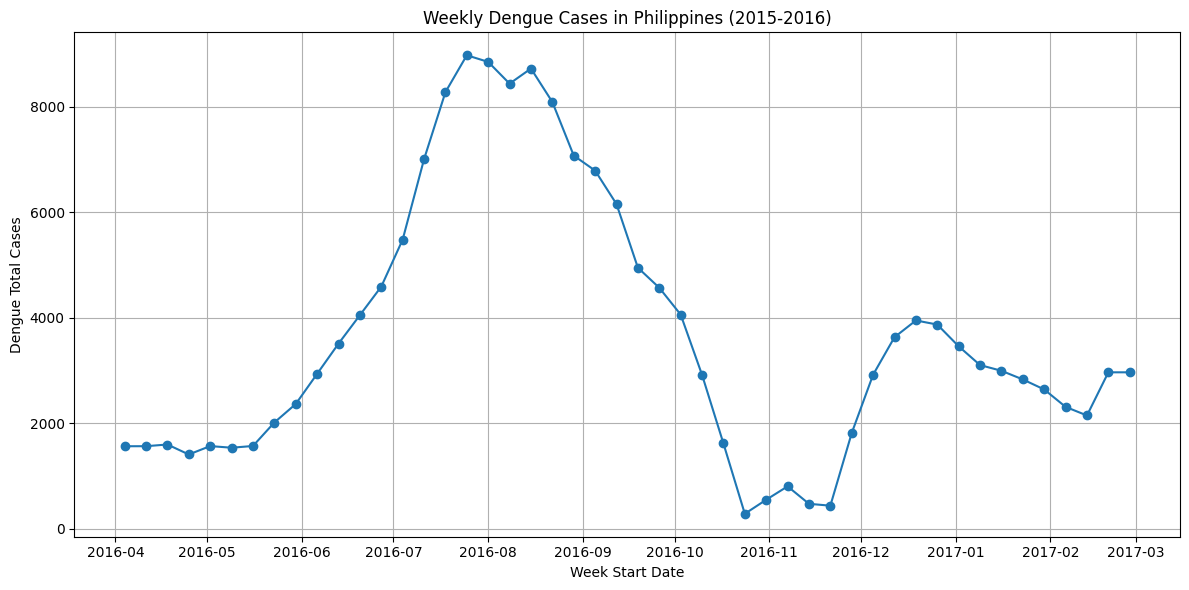

In [20]:
# Select data from a specific date range
start_date = "2016-04-01"
end_date = "2017-03-01"
chosen_range = weekly_philippines_cases[
    (weekly_philippines_cases["calendar_start_date"] >= start_date) &
    (weekly_philippines_cases["calendar_end_date"] <= end_date)
]

# Align calendar_start_date to Monday (or the weekday you use for full_weeks)
chosen_range = chosen_range.copy()
chosen_range["calendar_start_date"] = pd.to_datetime(chosen_range["calendar_start_date"])
chosen_range["calendar_start_date"] = chosen_range["calendar_start_date"] - pd.to_timedelta(chosen_range["calendar_start_date"].dt.weekday, unit='D')

# Set as index
chosen_range = chosen_range.set_index("calendar_start_date")
full_weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
chosen_range = chosen_range.reindex(full_weeks)

# Fill missing dengue_total with interpolation or median
chosen_range["dengue_total"] = chosen_range["dengue_total"].interpolate(method="quadratic")
chosen_range["dengue_total"] = chosen_range["dengue_total"].fillna(chosen_range["dengue_total"].median()).abs()

# Reconstruct calendar_end_date if needed
chosen_range["calendar_end_date"] = chosen_range.index + pd.Timedelta(days=6)

# Reset index for further use
chosen_range = chosen_range.reset_index().rename(columns={"index": "calendar_start_date"})

print(len(chosen_range))
plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Philippines (2015-2016)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../philippines/philippines_data_3.csv", index=False)

In [21]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

0    7.356918
1    8.050065
2    8.462315
3    8.723069
4    8.950533
Name: CumulativeHumanInfected, dtype: float64
0    1566.0
1    3133.0
2    4732.0
3    6142.0
4    7711.0
Name: CumulativeHumanInfected, dtype: float64
0    1566.0
1    3133.0
2    4732.0
3    6142.0
4    7711.0
Name: CumulativeHumanInfected, dtype: float64


48


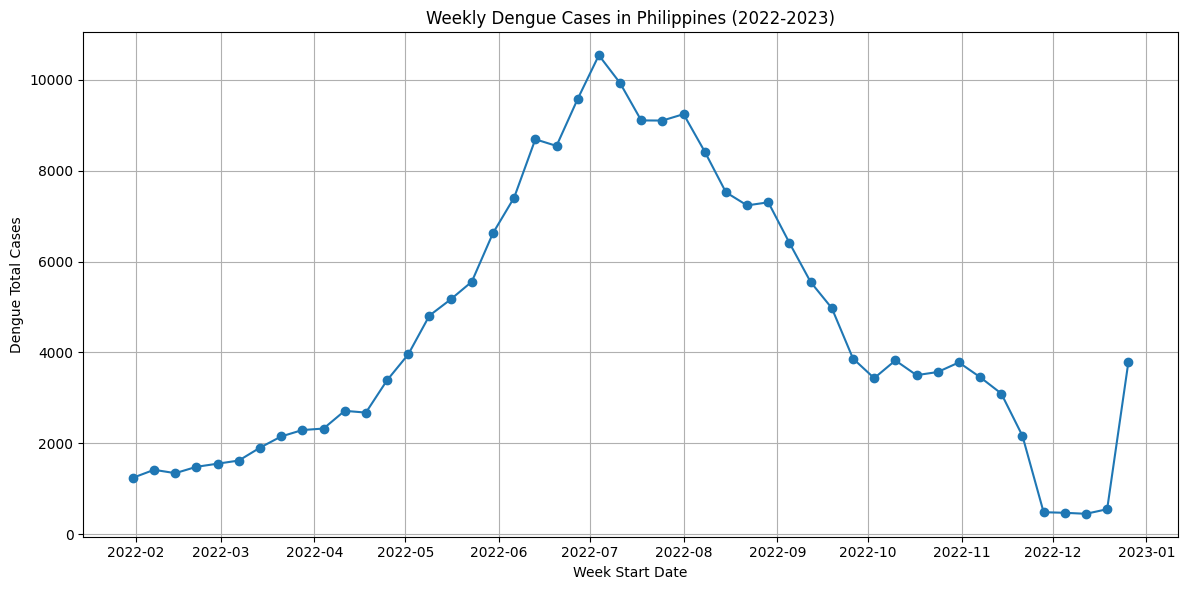

In [22]:
# Select data from a specific date range
start_date = "2022-01-25"
end_date = "2023-01-01"
chosen_range = weekly_philippines_cases[
    (weekly_philippines_cases["calendar_start_date"] >= start_date) &
    (weekly_philippines_cases["calendar_end_date"] <= end_date)
]

# Align calendar_start_date to Monday (or the weekday you use for full_weeks)
chosen_range = chosen_range.copy()
chosen_range["calendar_start_date"] = pd.to_datetime(chosen_range["calendar_start_date"])
chosen_range["calendar_start_date"] = chosen_range["calendar_start_date"] - pd.to_timedelta(chosen_range["calendar_start_date"].dt.weekday, unit='D')

# Set as index
chosen_range = chosen_range.set_index("calendar_start_date")
full_weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
chosen_range = chosen_range.reindex(full_weeks)

# Fill missing dengue_total with interpolation or median
chosen_range["dengue_total"] = chosen_range["dengue_total"].interpolate(method="quadratic")
chosen_range["dengue_total"] = chosen_range["dengue_total"].fillna(chosen_range["dengue_total"].median()).abs()

# Reconstruct calendar_end_date if needed
chosen_range["calendar_end_date"] = chosen_range.index + pd.Timedelta(days=6)

# Reset index for further use
chosen_range = chosen_range.reset_index().rename(columns={"index": "calendar_start_date"})

print(len(chosen_range))
plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Philippines (2022-2023)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
chosen_range["CumulativeHumanInfected"].to_csv("../../philippines/philippines_data_4.csv", index=False)

In [23]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

0    7.126087
1    7.886833
2    8.295549
3    8.610684
4    8.859789
Name: CumulativeHumanInfected, dtype: float64
0    1243.0
1    2661.0
2    4005.0
3    5489.0
4    7042.0
Name: CumulativeHumanInfected, dtype: float64
0    1243.0
1    2661.0
2    4005.0
3    5489.0
4    7042.0
Name: CumulativeHumanInfected, dtype: float64


## Process Cambodia (good data, chosen)

In [5]:
cambodia_cases = opendengue[opendengue["adm_0_name"] == "CAMBODIA"]
cambodia_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
86382,CAMBODIA,44.0,Banteay Meanchey,791.0,NaN,NaN,2000-09-01,2000-09-30,3.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
86383,CAMBODIA,44.0,Banteay Meanchey,791.0,NaN,NaN,2001-08-01,2001-08-31,455.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
86384,CAMBODIA,44.0,Banteay Meanchey,791.0,NaN,NaN,2003-03-01,2003-03-31,29.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
86385,CAMBODIA,44.0,Banteay Meanchey,791.0,NaN,NaN,2003-06-01,2003-06-30,234.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
86386,CAMBODIA,44.0,Banteay Meanchey,791.0,NaN,NaN,2004-05-01,2004-05-31,17.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [6]:
# Which cities in Cambodia have the most cases?
city_cases_cambodia = cambodia_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_cambodia.sort_values("dengue_total", ascending=False).head()
# Choose Phnom Penh

,adm_1_name,dengue_total
7,Kandal,26320.0
14,Phnom Penh,24686.0
2,Kampong Cham,22088.0
20,Siem Reap,21426.0
0,Banteay Meanchey,11461.0


In [7]:
# Sort by calendar_start_date and filter only weekly data
cambodia_cases["calendar_start_date"] = pd.to_datetime(cambodia_cases["calendar_start_date"])
cambodia_cases["calendar_end_date"] = pd.to_datetime(cambodia_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
cambodia_cases["period_days"] = (cambodia_cases["calendar_end_date"] - cambodia_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_cambodia_cases = cambodia_cases[
    # cambodia_cases["adm_1_name"].isnull() & 
    (cambodia_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_cambodia_cases = weekly_cambodia_cases[selected_columns]
weekly_cambodia_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total
139149,CAMBODIA,2011-01-02,2011-01-08,0.0
139105,CAMBODIA,2011-01-09,2011-01-15,0.0
138943,CAMBODIA,2011-01-16,2011-01-22,0.0
138944,CAMBODIA,2011-01-23,2011-01-29,0.0
139148,CAMBODIA,2011-01-30,2011-02-05,0.0


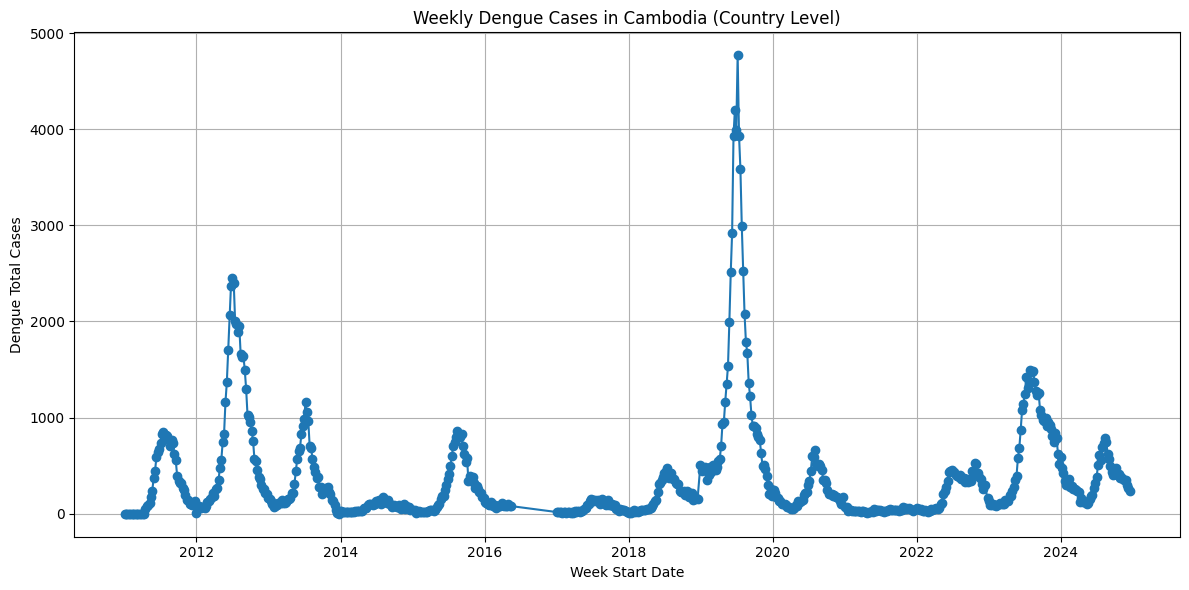

In [8]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_cambodia_cases["calendar_start_date"], weekly_cambodia_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Cambodia (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

### Weekly cases

48


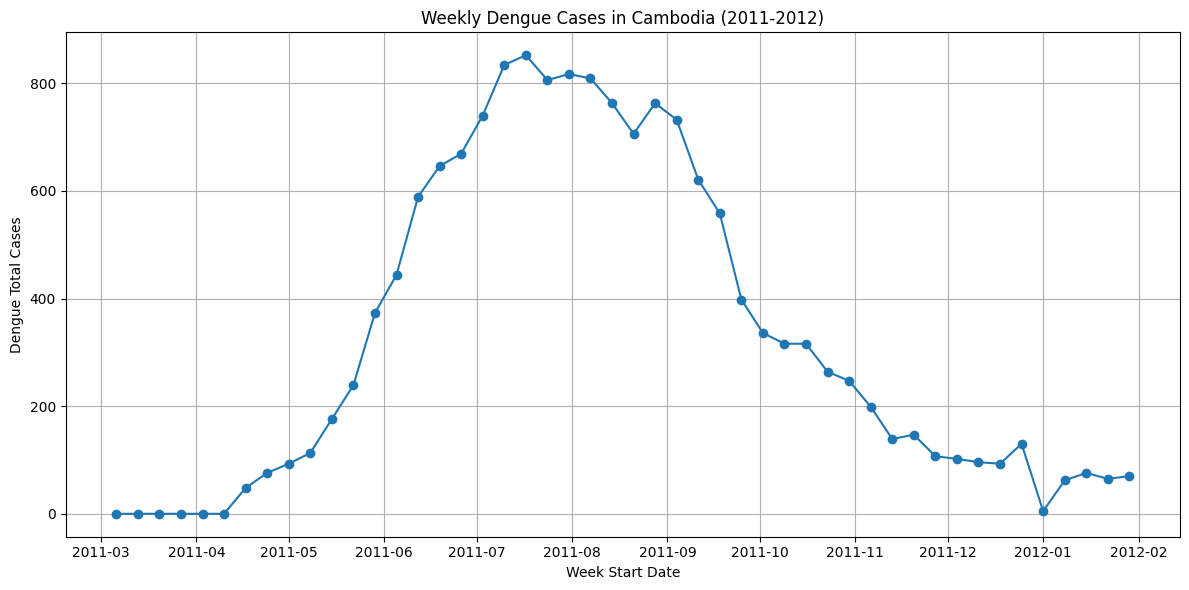

       adm_0_name calendar_start_date calendar_end_date  dengue_total  \
138955   CAMBODIA          2011-03-06        2011-03-12           0.0   
139022   CAMBODIA          2011-03-13        2011-03-19           0.0   
138994   CAMBODIA          2011-03-20        2011-03-26           0.0   
139048   CAMBODIA          2011-03-27        2011-04-02           0.0   
139020   CAMBODIA          2011-04-03        2011-04-09           0.0   
139059   CAMBODIA          2011-04-10        2011-04-16           0.0   
139085   CAMBODIA          2011-04-17        2011-04-23          48.0   
139129   CAMBODIA          2011-04-24        2011-04-30          76.0   
139115   CAMBODIA          2011-05-01        2011-05-07          93.0   
138991   CAMBODIA          2011-05-08        2011-05-14         113.0   
139087   CAMBODIA          2011-05-15        2011-05-21         176.0   
138927   CAMBODIA          2011-05-22        2011-05-28         239.0   
138899   CAMBODIA          2011-05-29        2011-0

In [9]:
# Select data from a specific date range
start_date = "2011-03-01"
end_date = "2012-02-05"
chosen_range = weekly_cambodia_cases[
    (weekly_cambodia_cases["calendar_start_date"] >= start_date) &
    (weekly_cambodia_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Cambodia (2011-2012)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../cambodia/cambodia_data_1.csv", index=False)
print(chosen_range)

48


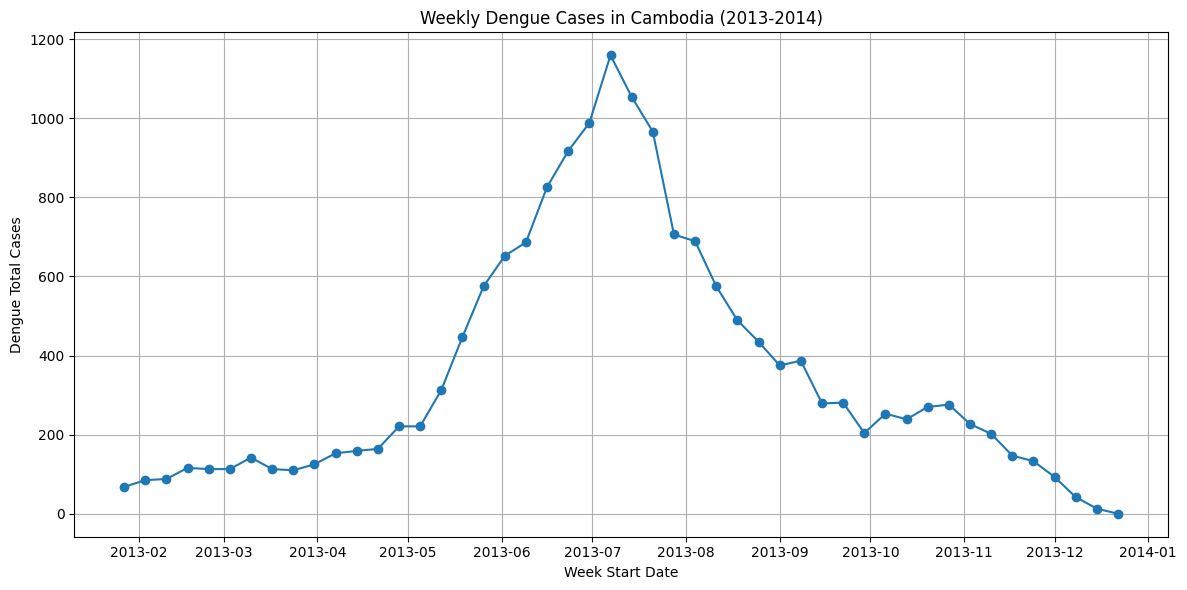

       adm_0_name calendar_start_date calendar_end_date  dengue_total  \
138946   CAMBODIA          2013-01-27        2013-02-02          68.0   
138929   CAMBODIA          2013-02-03        2013-02-09          85.0   
138919   CAMBODIA          2013-02-10        2013-02-16          88.0   
138906   CAMBODIA          2013-02-17        2013-02-23         116.0   
138989   CAMBODIA          2013-02-24        2013-03-02         113.0   
139044   CAMBODIA          2013-03-03        2013-03-09         113.0   
139035   CAMBODIA          2013-03-10        2013-03-16         142.0   
139052   CAMBODIA          2013-03-17        2013-03-23         113.0   
139050   CAMBODIA          2013-03-24        2013-03-30         110.0   
139038   CAMBODIA          2013-03-31        2013-04-06         125.0   
139136   CAMBODIA          2013-04-07        2013-04-13         153.0   
139122   CAMBODIA          2013-04-14        2013-04-20         159.0   
139110   CAMBODIA          2013-04-21        2013-0

In [10]:
# Select data from a specific date range
start_date = "2013-01-25"
end_date = "2014-01-01"
chosen_range = weekly_cambodia_cases[
    (weekly_cambodia_cases["calendar_start_date"] >= start_date) &
    (weekly_cambodia_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Cambodia (2013-2014)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../cambodia/cambodia_data_2.csv", index=False)
print(chosen_range)

48


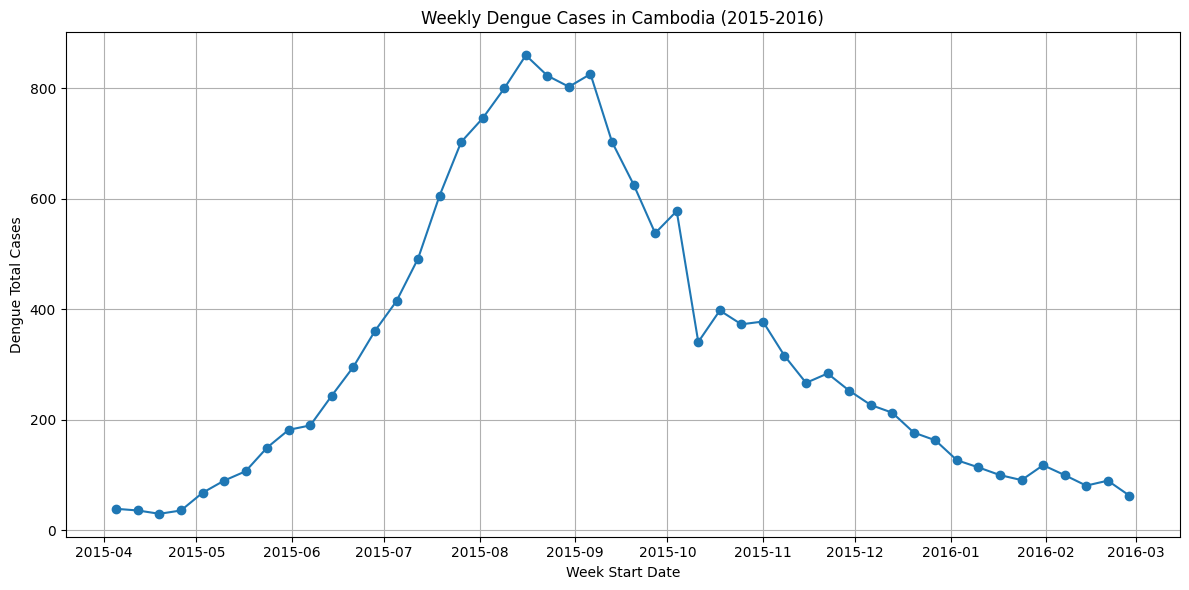

       adm_0_name calendar_start_date calendar_end_date  dengue_total  \
139100   CAMBODIA          2015-04-05        2015-04-11          39.0   
138993   CAMBODIA          2015-04-12        2015-04-18          36.0   
139005   CAMBODIA          2015-04-19        2015-04-25          30.0   
139032   CAMBODIA          2015-04-26        2015-05-02          36.0   
139058   CAMBODIA          2015-05-03        2015-05-09          68.0   
139113   CAMBODIA          2015-05-10        2015-05-16          90.0   
138950   CAMBODIA          2015-05-17        2015-05-23         107.0   
138924   CAMBODIA          2015-05-24        2015-05-30         150.0   
138898   CAMBODIA          2015-05-31        2015-06-06         182.0   
138910   CAMBODIA          2015-06-07        2015-06-13         190.0   
138900   CAMBODIA          2015-06-14        2015-06-20         244.0   
138914   CAMBODIA          2015-06-21        2015-06-27         296.0   
138928   CAMBODIA          2015-06-28        2015-0

In [13]:
# Select data from a specific date range
start_date = "2015-04-01"
end_date = "2016-03-05"
chosen_range = weekly_cambodia_cases[
    (weekly_cambodia_cases["calendar_start_date"] >= start_date) &
    (weekly_cambodia_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Cambodia (2015-2016)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../cambodia/cambodia_data_3.csv", index=False)
print(chosen_range)

48


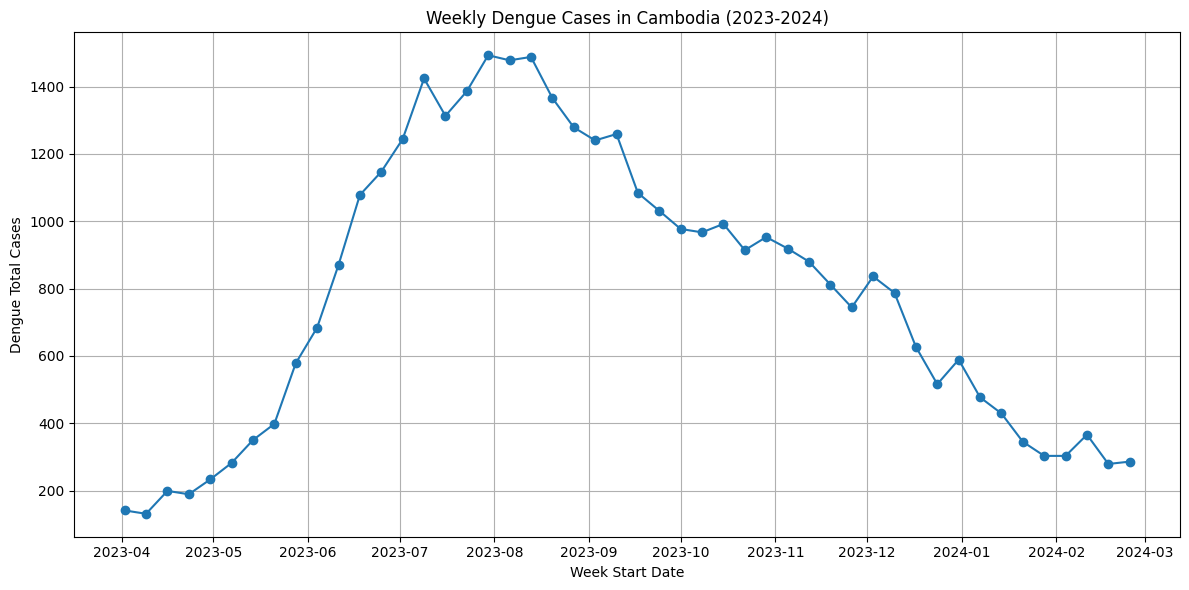

       adm_0_name calendar_start_date calendar_end_date  dengue_total  \
365092   CAMBODIA          2024-01-28        2024-02-03         303.0   
365093   CAMBODIA          2024-02-04        2024-02-10         303.0   
365094   CAMBODIA          2024-02-11        2024-02-17         366.0   
365095   CAMBODIA          2024-02-18        2024-02-24         279.0   
365096   CAMBODIA          2024-02-25        2024-03-02         286.0   

        CumulativeHumanInfected  
365092                  36432.0  
365093                  36735.0  
365094                  37101.0  
365095                  37380.0  
365096                  37666.0  


In [17]:
# Select data from a specific date range
start_date = "2023-04-01"
end_date = "2024-03-05"
chosen_range = weekly_cambodia_cases[
    (weekly_cambodia_cases["calendar_start_date"] >= start_date) &
    (weekly_cambodia_cases["calendar_end_date"] <= end_date)
]
print(len(chosen_range))

plt.figure(figsize=(12, 6))
plt.plot(chosen_range["calendar_start_date"], chosen_range["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Cambodia (2023-2024)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute cumulative cases
chosen_range["CumulativeHumanInfected"] = chosen_range["dengue_total"].cumsum()
# chosen_range["CumulativeHumanInfected"].to_csv("../../cambodia/cambodia_data_4.csv", index=False)
print(chosen_range.tail())

In [33]:
import numpy as np
print(np.log1p(chosen_range["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(chosen_range["CumulativeHumanInfected"])).head())
print(chosen_range["CumulativeHumanInfected"].head())

364974    4.955827
364975    5.609472
364976    6.156979
364977    6.493754
364978    6.795706
Name: CumulativeHumanInfected, dtype: float64
364974    141.0
364975    272.0
364976    471.0
364977    660.0
364978    893.0
Name: CumulativeHumanInfected, dtype: float64
364974    141.0
364975    272.0
364976    471.0
364977    660.0
364978    893.0
Name: CumulativeHumanInfected, dtype: float64


## Process Indonesia (no weekly)

In [6]:
indonesia_cases = opendengue[opendengue["adm_0_name"] == "INDONESIA"]
indonesia_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
94160,INDONESIA,116.0,Bali,1513.0,NaN,NaN,2005-05-01,2005-05-31,327.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94161,INDONESIA,116.0,Bali,1513.0,NaN,NaN,2005-08-01,2005-08-31,109.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94162,INDONESIA,116.0,Bali,1513.0,NaN,NaN,2004-01-01,2004-01-31,69.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94163,INDONESIA,116.0,Bali,1513.0,NaN,NaN,2004-02-01,2004-02-29,439.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94164,INDONESIA,116.0,Bali,1513.0,NaN,NaN,2004-03-01,2004-03-31,890.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [7]:
# Which cities in Indonesia have the most cases?
city_cases_indonesia = indonesia_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_indonesia.sort_values("dengue_total", ascending=False).head()
# Choose Jakarta

,adm_1_name,dengue_total
23,Jawa Barat,575439.0
19,JAWA BARAT,439821.0
25,Jawa Timur,389798.0
13,DKI Jakarta,329641.0
24,Jawa Tengah,309343.0


In [12]:
# Sort by calendar_start_date and filter only weekly data
indonesia_cases["calendar_start_date"] = pd.to_datetime(indonesia_cases["calendar_start_date"])
indonesia_cases["calendar_end_date"] = pd.to_datetime(indonesia_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
indonesia_cases["period_days"] = (indonesia_cases["calendar_end_date"] - indonesia_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_indonesia_cases = indonesia_cases[
    # indonesia_cases["adm_1_name"].isnull() & 
    (indonesia_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_indonesia_cases = weekly_indonesia_cases[selected_columns]
weekly_indonesia_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total


## Process Thailand (no weekly)

In [13]:
thailand_cases = opendengue[opendengue["adm_0_name"] == "THAILAND"]
thailand_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
90404,THAILAND,240.0,Chiang Rai,2860.0,NaN,NaN,2006-03-01,2006-03-31,1.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90405,THAILAND,240.0,Chiang Rai,2860.0,NaN,NaN,2006-06-01,2006-06-30,4.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90406,THAILAND,240.0,Chiang Rai,2860.0,NaN,NaN,2006-07-01,2006-07-31,5.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90407,THAILAND,240.0,Chiang Rai,2860.0,NaN,NaN,2006-09-01,2006-09-30,3.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90408,THAILAND,240.0,Chiang Rai,2860.0,NaN,NaN,2006-11-01,2006-11-30,2.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [14]:
# Which cities in Thailand have the most cases?
city_cases_thailand = thailand_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_thailand.sort_values("dengue_total", ascending=False).head()
# Choose Bangkok

,adm_1_name,dengue_total
2,Bangkok,181691.0
28,Nakhon Ratchasima,68956.0
30,Nakhon Si Thammarat,59178.0
9,Chiang Mai,58629.0
64,Songkhla,47520.0


In [ ]:
# Sort by calendar_start_date and filter only weekly data
thailand_cases["calendar_start_date"] = pd.to_datetime(thailand_cases["calendar_start_date"])
thailand_cases["calendar_end_date"] = pd.to_datetime(thailand_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
thailand_cases["period_days"] = (thailand_cases["calendar_end_date"] - thailand_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_thailand_cases = thailand_cases[
    # thailand_cases["adm_1_name"].isnull() & 
    (thailand_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_thailand_cases = weekly_thailand_cases[selected_columns]
weekly_thailand_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total


In [ ]:
# Check weekly data (Thailand)s
thailand_cases[thailand_cases['period_days'] < 10].head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID,period_days


## Process Malaysia (have weekly, but ugly data)

In [19]:
malaysia_cases = opendengue[opendengue["adm_0_name"] == "MALAYSIA"]
malaysia_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
90062,MALAYSIA,153.0,Sarawak,1902.0,NaN,NaN,2001-09-01,2001-09-30,50.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90063,MALAYSIA,153.0,Sarawak,1902.0,NaN,NaN,2001-10-01,2001-10-31,53.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90064,MALAYSIA,153.0,Sarawak,1902.0,NaN,NaN,2005-12-01,2005-12-31,221.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90065,MALAYSIA,153.0,Sarawak,1902.0,NaN,NaN,2006-09-01,2006-09-30,105.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
90066,MALAYSIA,153.0,Sarawak,1902.0,NaN,NaN,2008-02-01,2008-02-29,151.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [20]:
# Which cities in Malaysia have the most cases?
city_cases_malaysia = malaysia_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_malaysia.sort_values("dengue_total", ascending=False).head()
# Choose Kuala Lumpur

,adm_1_name,dengue_total
13,Selangor,513000.0
0,Johor,117815.0
8,Perak,81347.0
2,Kelantan,61997.0
3,Kuala Lumpur,55253.0


In [21]:
# Sort by calendar_start_date and filter only weekly data
malaysia_cases["calendar_start_date"] = pd.to_datetime(malaysia_cases["calendar_start_date"])
malaysia_cases["calendar_end_date"] = pd.to_datetime(malaysia_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
malaysia_cases["period_days"] = (malaysia_cases["calendar_end_date"] - malaysia_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_malaysia_cases = malaysia_cases[
    malaysia_cases["adm_1_name"].isnull() & 
    (malaysia_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_malaysia_cases = weekly_malaysia_cases[selected_columns]
weekly_malaysia_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total
442778,MALAYSIA,2011-01-02,2011-01-08,520.0
442780,MALAYSIA,2011-01-09,2011-01-15,597.0
442782,MALAYSIA,2011-01-16,2011-01-22,490.0
442785,MALAYSIA,2011-01-23,2011-01-29,494.0
442786,MALAYSIA,2011-01-30,2011-02-05,371.0


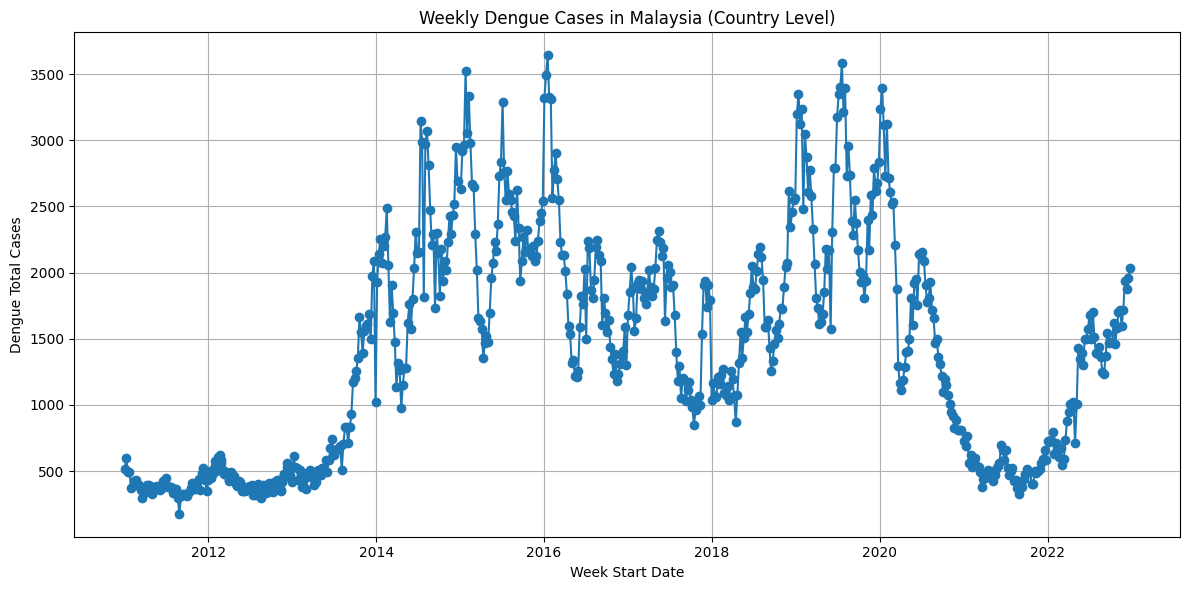

In [22]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_malaysia_cases["calendar_start_date"], weekly_malaysia_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Malaysia (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## Process India (no weekly)

In [ ]:
india_cases = opendengue[opendengue["adm_0_name"] == "INDIA"]
india_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
94128,INDIA,115.0,NaN,NaN,NaN,NaN,1993-01-01,1993-12-31,11125.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94129,INDIA,115.0,NaN,NaN,NaN,NaN,1996-01-01,1996-12-31,16517.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94130,INDIA,115.0,NaN,NaN,NaN,NaN,2000-01-01,2000-12-31,650.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94131,INDIA,115.0,NaN,NaN,NaN,NaN,2003-01-01,2003-12-31,12754.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
94132,INDIA,115.0,NaN,NaN,NaN,NaN,2004-01-01,2004-12-31,4153.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [25]:
# Which cities in India have the most cases?
city_cases_india = india_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_india.sort_values("dengue_total", ascending=False).head()
# Choose Delhi

,adm_1_name,dengue_total
44,West Bengal,198865.0
35,Punjab,148475.0
41,Uttar Pradesh,144377.0
22,Karnataka,139893.0
26,Maharashtra,123966.0


In [27]:
# Sort by calendar_start_date and filter only weekly data
india_cases["calendar_start_date"] = pd.to_datetime(india_cases["calendar_start_date"])
india_cases["calendar_end_date"] = pd.to_datetime(india_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
india_cases["period_days"] = (india_cases["calendar_end_date"] - india_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_india_cases = india_cases[
    # india_cases["adm_1_name"].isnull() & 
    (india_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_india_cases = weekly_india_cases[selected_columns]
weekly_india_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total


## Process Singapore (have weekly, but ugly data)

In [29]:
singapore_cases = opendengue[opendengue["adm_0_name"] == "SINGAPORE"]
singapore_cases.head()

,adm_0_name,adm_0_code,adm_1_name,adm_1_code,adm_2_name,adm_2_code,calendar_start_date,calendar_end_date,dengue_total,raw_data,case_definition_standardised,UUID
103656,SINGAPORE,222.0,NaN,NaN,NaN,NaN,1973-01-01,1973-12-31,1187.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
103657,SINGAPORE,222.0,NaN,NaN,NaN,NaN,1974-01-01,1974-12-31,229.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
103658,SINGAPORE,222.0,NaN,NaN,NaN,NaN,1975-01-01,1975-12-31,59.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
103659,SINGAPORE,222.0,NaN,NaN,NaN,NaN,1980-01-01,1980-12-31,253.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00
103660,SINGAPORE,222.0,NaN,NaN,NaN,NaN,1983-01-01,1983-12-31,205.0,V1_0_open_dengue_asia.csv,Total,TYCHO-ALL-19242017-SV_DF01-00


In [30]:
# Which cities in Singapore have the most cases?
city_cases_singapore = singapore_cases.groupby("adm_1_name")["dengue_total"].sum().reset_index()
city_cases_singapore.sort_values("dengue_total", ascending=False).head()
# Choose Singapore

,adm_1_name,dengue_total
0,Central Singapore,81831.0


In [31]:
# Sort by calendar_start_date and filter only weekly data
singapore_cases["calendar_start_date"] = pd.to_datetime(singapore_cases["calendar_start_date"])
singapore_cases["calendar_end_date"] = pd.to_datetime(singapore_cases["calendar_end_date"])
selected_columns = [
    "adm_0_name", "calendar_start_date", 
    "calendar_end_date", "dengue_total"
]

# Calculate the difference in days
singapore_cases["period_days"] = (singapore_cases["calendar_end_date"] - singapore_cases["calendar_start_date"]).dt.days

# Filter for weekly data (difference == 6 or 7 days)
weekly_singapore_cases = singapore_cases[
    # singapore_cases["adm_1_name"].isnull() & 
    (singapore_cases["period_days"].between(6, 7))
].sort_values("calendar_start_date")

weekly_singapore_cases = weekly_singapore_cases[selected_columns]
weekly_singapore_cases.head()

,adm_0_name,calendar_start_date,calendar_end_date,dengue_total
160921,SINGAPORE,2001-12-30,2002-01-05,20.0
160913,SINGAPORE,2002-01-06,2002-01-12,22.0
160924,SINGAPORE,2002-01-13,2002-01-19,22.0
160931,SINGAPORE,2002-01-20,2002-01-26,18.0
160923,SINGAPORE,2002-01-27,2002-02-02,19.0


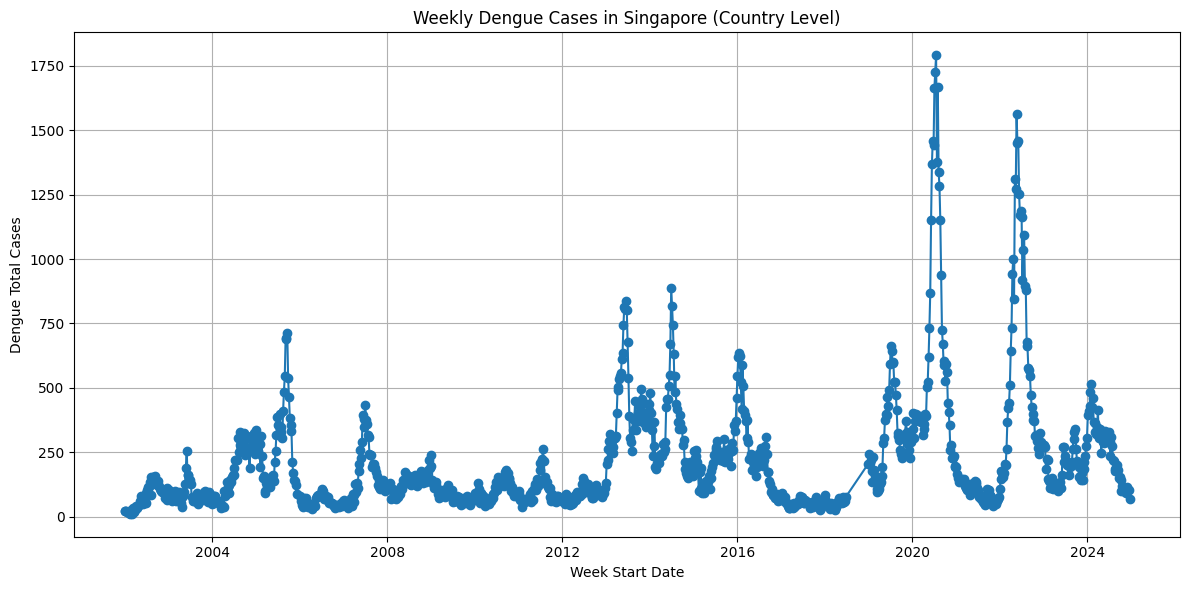

In [32]:
import matplotlib.pyplot as plt

# Visualize weekly_country_cases by dengue_total values
plt.figure(figsize=(12, 6))
plt.plot(weekly_singapore_cases["calendar_start_date"], weekly_singapore_cases["dengue_total"], marker='o')
plt.title("Weekly Dengue Cases in Singapore (Country Level)")
plt.xlabel("Week Start Date")
plt.ylabel("Dengue Total Cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## Process Myanmar (no weekly)